# Requirements check

In [1]:
import sys
import datetime
print(sys.version)

3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:20:16) [MSC v.1916 64 bit (AMD64)]


In [2]:
import darts
print(darts.__version__)

0.37.1


# Install dependencies

In [3]:
# cell A: which Python executable and environment
import sys, os
print("sys.executable:", sys.executable)
print("sys.version:", sys.version.replace('\n',' '))
print("PATH contains CUDA:", any("CUDA" in p or "cudnn" in p.lower() for p in os.environ.get("PATH","").split(os.pathsep)))


sys.executable: C:\Users\omirz\anaconda3\envs\sber_inputs_2\python.exe
sys.version: 3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:20:16) [MSC v.1916 64 bit (AMD64)]
PATH contains CUDA: True


In [4]:
# cell B: torch diagnostics (safe if torch absent)
try:
    import torch
    print("torch.__version__:", torch.__version__)
    print("torch.version.cuda:", torch.version.cuda)
    print("torch.cuda.is_available():", torch.cuda.is_available())
    print("cuda device count:", torch.cuda.device_count())
    if torch.cuda.is_available():
        print("device name:", torch.cuda.get_device_name(0))
except Exception as e:
    print("import torch failed / torch not found:", e)


torch.__version__: 2.5.1
torch.version.cuda: 12.1
torch.cuda.is_available(): True
cuda device count: 1
device name: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [5]:
import torch

torch.cuda.is_available()

True

In [ ]:
!pip install -r requirements.txt

## Imports

In [1]:
from utils.constants import (
    CATEGORY_MAP,
    BEST_PREDICTORS_FOR_INDEX
)
from utils.utils import (
    plot_known_feature_value,
    plot_graphics_for_each_ts,
    get_month_beginnings
)
import numpy as np
from utils.parametrized_values import (
    form_df_future,
    load_models,
    form_input_to_forecasting,
    train_model_and_eval_res,
    get_prediction_for_ts,
    df_combined,
    macro_data
)
from utils.cluster_forecast import ClusterForecaster
from itertools import combinations
from typing import Type, Literal, Any
from darts import TimeSeries
import pandas as pd
import os
from dateutil.relativedelta import relativedelta

import warnings
warnings.filterwarnings('ignore')

Index(['USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       'Сахар (средняя цена по России)', 'Свинина в живом весе',
       'Соевое масло', 'Соевый шрот', 'Соя', 'Яйцо товарное',
       'Подсолнечное масло наливом (мировые цены)',
       'Бутилированное подсолнечное масло (рафинированное)',
       'Подсолнечный шрот ', 'Колбасы сырокопченые', 'Баранина в живом весе',
       'Баранина в убойном весе ', 'Какао-бобы (USD)', 'Какао-бобы',
       'Подсолнечное масло (наливом) не бутилированное, нерафинированное ',
       'Кокосовое масло (USD) ', 'Кокосовое масло ', 'Пальмовое масло (USD)',
       'Пальмовое масло ', 'Табак (USD)', 'Табак', 'Пшеница 4-го класса',
       'Минтай б/г, Владивосток руб./кг', 'Минтай б/г, Китай C&F $/т',
       'Сельдь н/р, Владивосток руб./кг', 'Огурцы тепличные, руб./кг',
       '

---
## Global parameters setting

In [2]:
print(f"Available columns to predict: {df_combined.columns}, {macro_data.columns}")

Available columns to predict: Index(['USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       'Сахар (средняя цена по России)',
       ...
       'Масла и шроты_norm_sum', 'Животноводство и мясо_norm_sum',
       'Переработанное мясо_norm_sum', 'Рыба_norm_sum', 'Овощи_norm_sum',
       'Сахар и мука_norm_sum', 'Стимулирующие культуры_norm_sum',
       'Удобрения и агрохимикаты_norm_sum', 'Органические химикаты_norm_sum',
       'USDRUB_norm_sum'],
      dtype='object', length=109), Index(['Инфляция - Рост индекса цен производителей (RUB, eop PPI),',
       'Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),',
       'Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),',
       'Ключевая ставка, годовых', 'Инфляция, г/г'],
      dtype='object')


## Описание параметров запуска

### Основные параметры прогнозирования
- `PREDICTION_HORIZON = 12` - горизонт прогнозирования (месяцев)
- `PREDICTOR_LAG = 12` - лаг предикторов

### Режимы работы и даты
- `IS_BACKTEST: bool = True` - режим бэктеста (True - тестирование на исторических данных, False - реальный прогноз)
- `BACKTEST_DATE` - дата начала бэктеста
- `SINGLE_DATAPOINT_TO_PRED = "2026-04-14"` - целевая дата для прогноза

### Параметры моделей
- `TARGET_COL_SUFFIX = "_sum"` - суффикс целевой переменной
- `MODEL_NAME_FOR_FORECASTER = "nbeats"` - тип модели для прогнозирования
- `USE_FUTURE_COV` - использование будущих ковариат (автоматически определяется по типу модели)

### Временные параметры
- `FUTURE_DATE` - будущая дата значений
- `train_end` - конец обучающего периода
- `past_idx` - даты исторических данных для обучения
- `future_idx` - даты будущего периода для прогноза

### Параметры внешних факторов
- `FUTURE_FORECASTER_TS_NAME = "Инфляция, г/г"` - название макроэкономического показателя
- `FUTURE_FORECASTER_TS_VALUES` - известные будущие значения макропоказателя

### Управление моделями
- `MODEL_SAVE_PATH` - шаблон пути для сохранения моделей
- `PERSIST_MODEL = True` - флаг сохранения моделей на диск
- `REFIT_MODEL = True` - флаг переобучения моделей

In [3]:
SINGLE_DATAPOINT_TO_PRED = "2027-01-01"

IS_BACKTEST: bool = df_combined.index[-1] >= pd.to_datetime(SINGLE_DATAPOINT_TO_PRED)
BACKTEST_PREDICTION_RANGE = 12 if IS_BACKTEST else 0

new_dates = pd.date_range(start=df_combined.index[-1] + pd.DateOffset(months=1),
                      end=SINGLE_DATAPOINT_TO_PRED,
                      freq='MS') if not IS_BACKTEST else \
            pd.date_range(start=pd.to_datetime(SINGLE_DATAPOINT_TO_PRED) - pd.DateOffset(months=BACKTEST_PREDICTION_RANGE) + pd.DateOffset(months=1),
                      end=SINGLE_DATAPOINT_TO_PRED,
                      freq='MS')

PREDICTION_HORIZON = len(new_dates) if not IS_BACKTEST else BACKTEST_PREDICTION_RANGE


FUTURE_VALUES = {
    "Кукуруза": 15.5,
    # "Пшеница 1-го класса": 0.0,
    # "Пшеница 3-го класса": 0.0,
    # "Пшеница 4-го класса": 0.0,
    # "Пшеница 5-го класса": 0.0,
    # "Пшеница 12,5% FOB Ново, $ т": 0.0,
    # "Подсолнечник": 20.8,
    # "Соя": 0.0,
    # "Рапс, руб. т": 0.0,
    # # Oils & Meals
    # "Подсолнечное масло наливом (мировые цены)": 0.0,
    # "Бутилированное подсолнечное масло (рафинированное)": 0.0,
    # "Подсолнечное масло (наливом) не бутилированное, нерафинированное ": 0.0,
    # "Подсолнечное масло (наливом) не бутилированное, не": 0.0,
    # "Подсолнечный шрот ": 0.0,
    "Соевое масло": 900.0,
    # "Соевый шрот": 0.0,
    # "Рапсовое масло EU, $ т": 0.0,
    # "Кокосовое масло ": 0.0,
    # "Пальмовое масло ": 0.0,
    # # Livestock
    "Молоко сырое": 43.0,
    # "Мясо птицы бройлеров в живом весе ": 0.0,
    # "Мясо крупного рогатого скота в живом весе ": 0.0,
    # "Свинина в живом весе": 0.0,
    # "Баранина в живом весе": 0.0,
    # "Баранина в убойном весе ": 0.0,
    # "Яйцо товарное": 0.0,
    # # Processed meat
    # "Колбасы сырокопченые": 0.0,
    # "Колбасы вареные": 0.0,
    # # Fish
    # "Минтай б г, Владивосток руб. кг": 0.0,
    # "Минтай б г, Китай C&F $ т": 0.0,
    # "Сельдь н р, Владивосток руб. кг": 0.0,
    # # Vegetables
    "Огурцы тепличные, руб. кг": 130.0,
    # "Томаты тепличные, руб. кг": 0.0,
    # # Other
    # "Сахар (средняя цена по России)": 0.0,
    # "Мука пшеничная, руб. т": 0.0,
    # # Stimuli crops
    # "Какао-бобы": 0.0,
    # "Табак": 0.0,
    # # Chemicals - dip
    # "Карбамид (FOB Южный)": 0.0,
    # "Моноаммонийфосфат, MAP (FOB Балтика)": 0.0,
    # "Апатитовый концетрат (FOB Morocco)": 0.0,
    # "Аммиак (FOB Черное море)": 0.0,
    # "Аммиачная селитра (FOB Черное море)": 0.0,
    # "Хлорид калия (CFR Ю-В Азия)": 0.0,
    # # Chemicals - bump
    # "Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия": 0.0,
    # "Метанол": 0.0,
    # "Бензол, CFR Япония": 0.0,
    # "Этилен, CFR Китай": 0.0,
    # # macros
    # "Инфляция - Рост индекса цен производителей (RUB, eop PPI),": 0.0,
    # "Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),": 0.0,
    # "Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),": 0.0,
    # "Ключевая ставка, годовых": 12.3,
    # "Инфляция, г/г": 8.9,
    # "USDRUB": 0.0
}
selected_clusters = [CATEGORY_MAP[i] for i in FUTURE_VALUES.keys()]

if len(selected_clusters) != len(set(selected_clusters)):
    print("The elements must belong to different clusters.")

FUTURE_FORECASTER_TS_NAME = list(FUTURE_VALUES.keys())  # ["Подсолнечник", "Ключевая ставка, годовых", "Инфляция, г/г"]
FUTURE_FORECASTER_TS_VALUES_RAW = list(FUTURE_VALUES.values())

BACKTEST_DATE = df_combined.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON)
TS_FREQUENCY = "MS"
train_end = BACKTEST_DATE if not IS_BACKTEST else pd.to_datetime(SINGLE_DATAPOINT_TO_PRED) - pd.DateOffset(months=BACKTEST_PREDICTION_RANGE)


if IS_BACKTEST:
    past_idx = pd.date_range(start=pd.to_datetime(SINGLE_DATAPOINT_TO_PRED) - pd.DateOffset(months=BACKTEST_PREDICTION_RANGE) + pd.DateOffset(months=1),
                               periods=PREDICTION_HORIZON,
                               freq=TS_FREQUENCY)
    future_idx = None
    
else:
    past_idx = pd.date_range(start=train_end + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq=TS_FREQUENCY)
    future_idx = pd.date_range(start=past_idx[-1] + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq=TS_FREQUENCY)

PERSIST_MODEL = True
REFIT_MODEL = True

PREDICTOR_LAG = 12
MODEL_SAVE_PATH = "{model_name}_dataset/{model_name}_for_{category_name}" + f"__{PREDICTION_HORIZON}"
TARGET_COL_SUFFIX = "_norm_sum"
MODEL_NAME_FOR_FORECASTER: Literal["tftmodel", "nbeats", "naiveseasonal", "chronos", "randomforest"] = "randomforest"
USE_FUTURE_COV = MODEL_NAME_FOR_FORECASTER in ("tftmodel", "randomforest", "chronos")

if IS_BACKTEST:
    df_updated = df_combined
    df_updated.columns = [col.replace("/", " ") for col in df_updated.columns]
    
    macro_updated = macro_data
    FUTURE_FORECASTER_TS_VALUES = []
    for (ts_name, ts_val) in zip(FUTURE_FORECASTER_TS_NAME, FUTURE_FORECASTER_TS_VALUES_RAW):
        df_target = df_updated if ts_name in df_updated.columns else macro_updated
        df_target.loc[past_idx, ts_name] = np.linspace(df_target.loc[past_idx].iloc[0][ts_name], ts_val, PREDICTION_HORIZON)
        FUTURE_FORECASTER_TS_VALUES.append(df_target.loc[past_idx][ts_name].values)
else:
    df_updated, macro_updated, FUTURE_FORECASTER_TS_VALUES = form_df_future(new_dates,
                                                                           FUTURE_FORECASTER_TS_NAME,
                                                                           FUTURE_FORECASTER_TS_VALUES_RAW,
                                                                           PREDICTION_HORIZON
                                                                       )

---
## Forecasting clusers

### predictions

Could not calculate mape for prediction due to index 0 is out of bounds for axis 0 with size 0


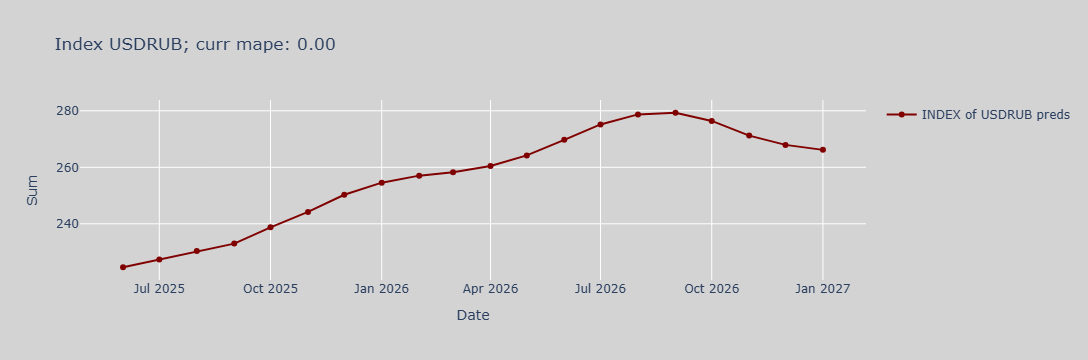

Saved forecaster to randomforest_dataset/randomforest_for_USDRUB__20.pkl and model to randomforest_dataset/randomforest_for_USDRUB__20_model.pth
Could not calculate mape for prediction due to index 0 is out of bounds for axis 0 with size 0


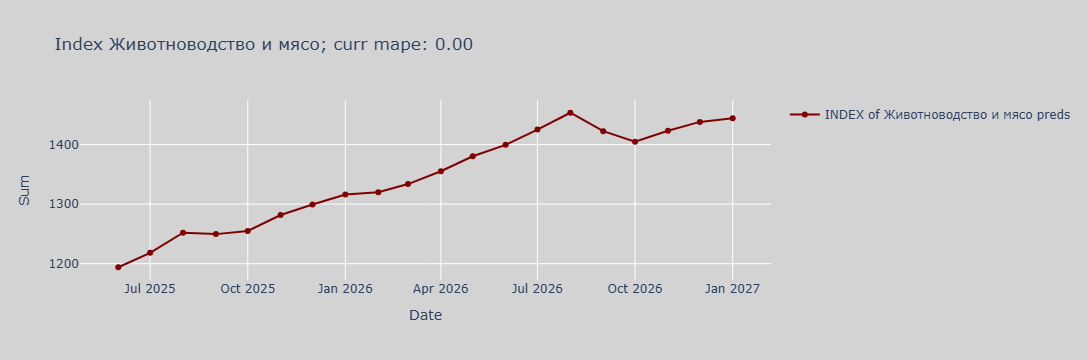

Saved forecaster to randomforest_dataset/randomforest_for_Животноводство и мясо__20.pkl and model to randomforest_dataset/randomforest_for_Животноводство и мясо__20_model.pth
Could not calculate mape for prediction due to index 0 is out of bounds for axis 0 with size 0


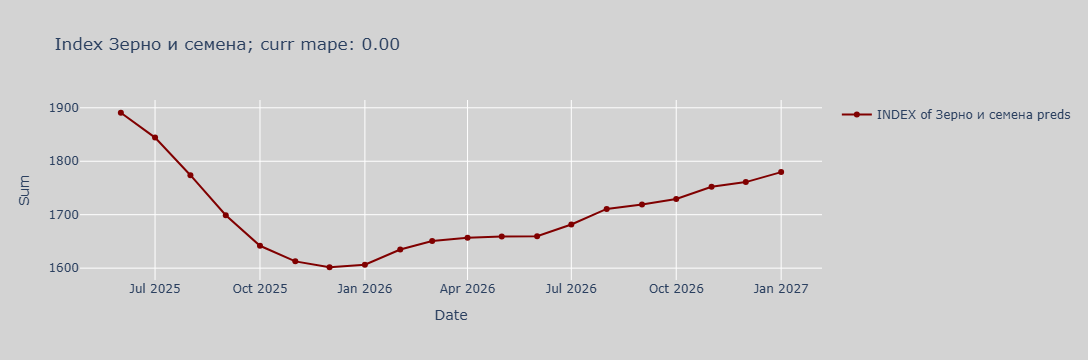

Saved forecaster to randomforest_dataset/randomforest_for_Зерно и семена__20.pkl and model to randomforest_dataset/randomforest_for_Зерно и семена__20_model.pth


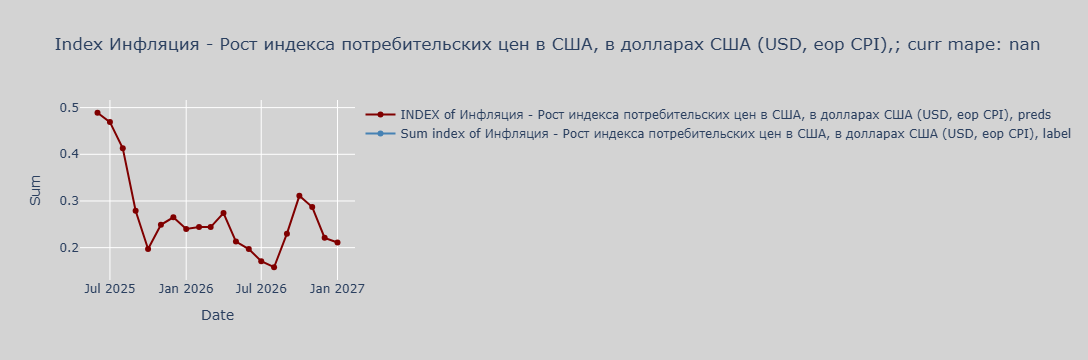

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),__20.pkl and model to randomforest_dataset/randomforest_for_Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),__20_model.pth


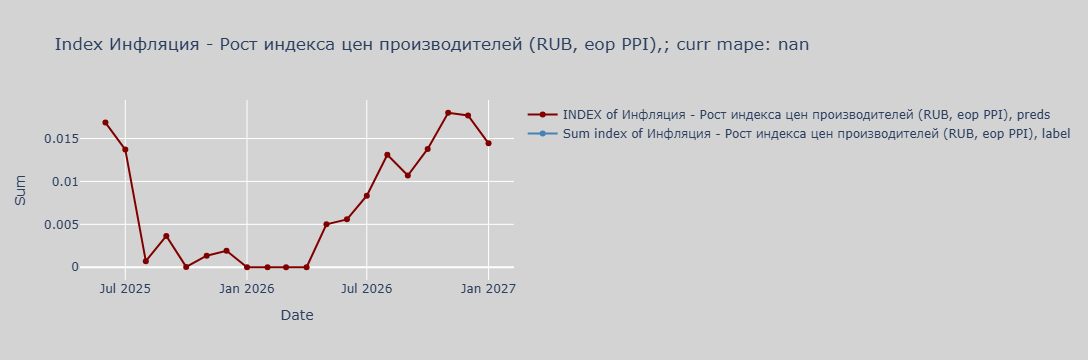

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей (RUB, eop PPI),__20.pkl and model to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей (RUB, eop PPI),__20_model.pth


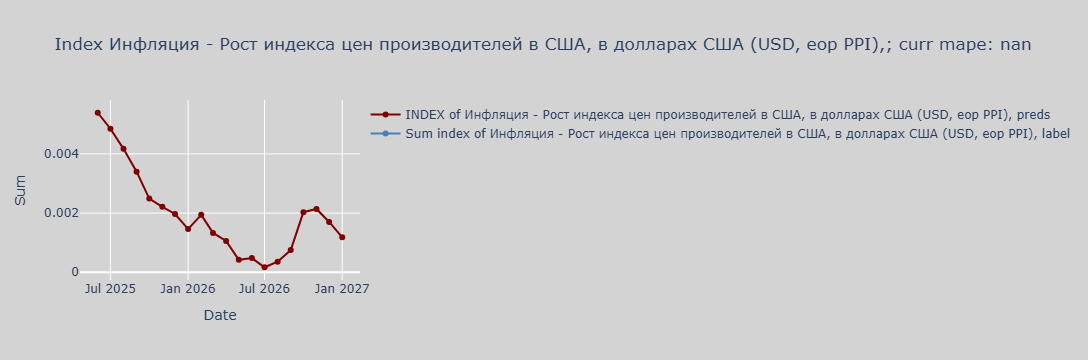

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),__20.pkl and model to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),__20_model.pth


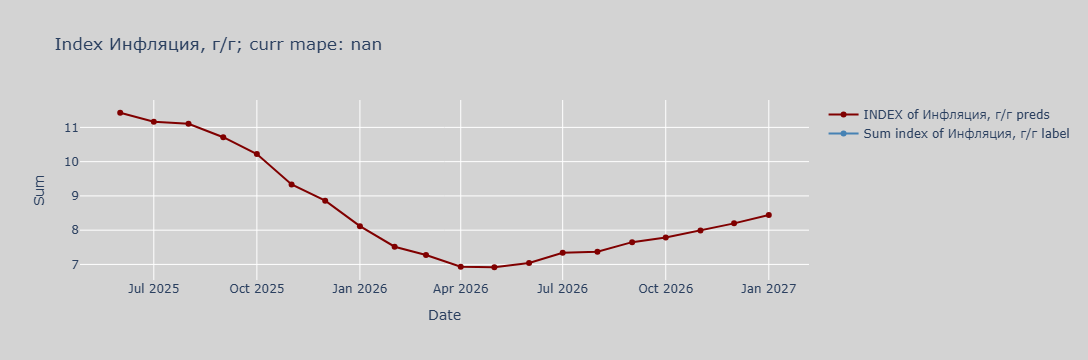

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция, г_г__20.pkl and model to randomforest_dataset/randomforest_for_Инфляция, г_г__20_model.pth
Warning! The additional cluster column does not exists in cluster_data
Warning! There is no Инфляция - Рост индекса цен производителей (RUB, eop PPI),_norm_sum at df


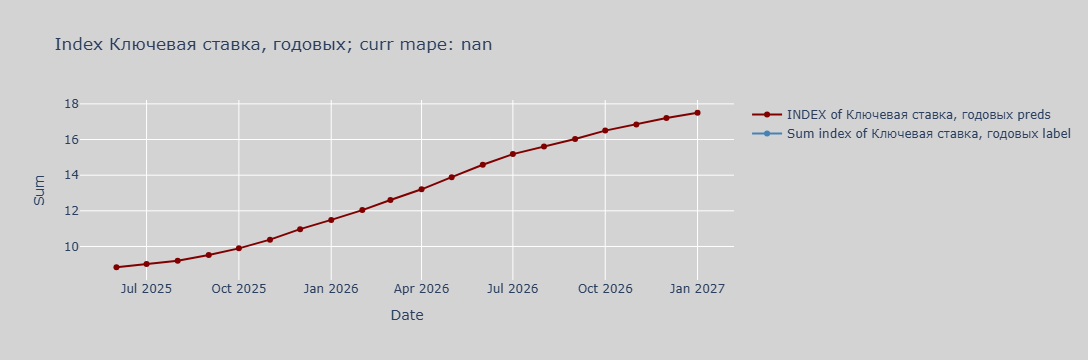

Saved forecaster to randomforest_dataset/randomforest_for_Ключевая ставка, годовых__20.pkl and model to randomforest_dataset/randomforest_for_Ключевая ставка, годовых__20_model.pth
Could not calculate mape for prediction due to index 0 is out of bounds for axis 0 with size 0


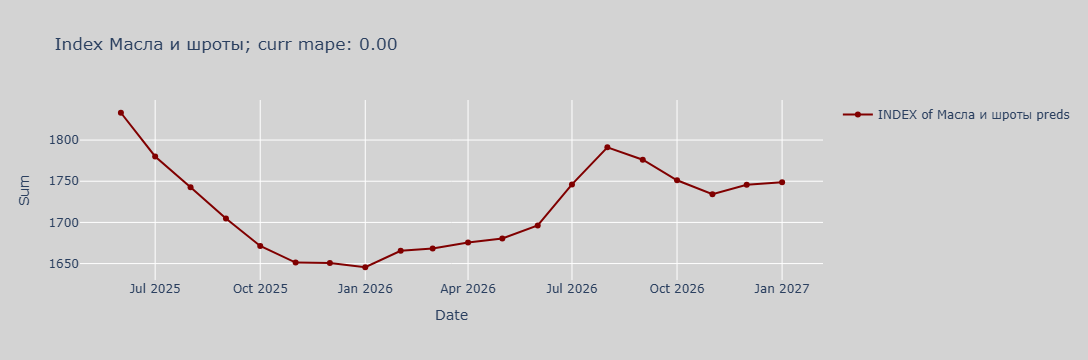

Saved forecaster to randomforest_dataset/randomforest_for_Масла и шроты__20.pkl and model to randomforest_dataset/randomforest_for_Масла и шроты__20_model.pth
Could not calculate mape for prediction due to index 0 is out of bounds for axis 0 with size 0


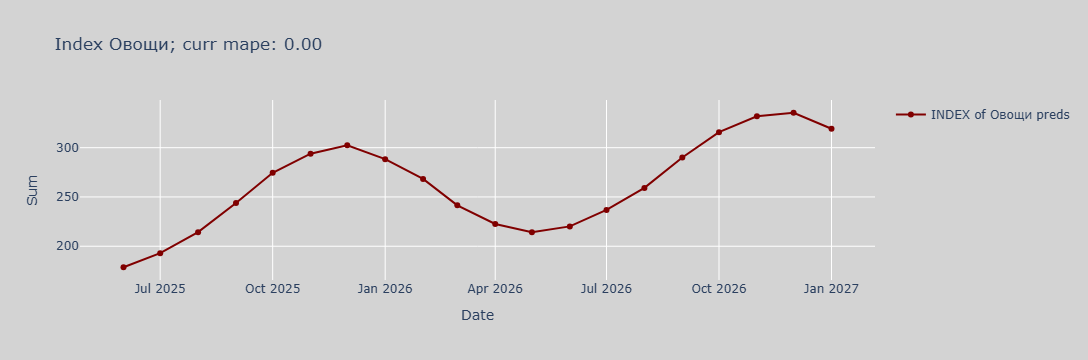

Saved forecaster to randomforest_dataset/randomforest_for_Овощи__20.pkl and model to randomforest_dataset/randomforest_for_Овощи__20_model.pth
Could not calculate mape for prediction due to index 0 is out of bounds for axis 0 with size 0


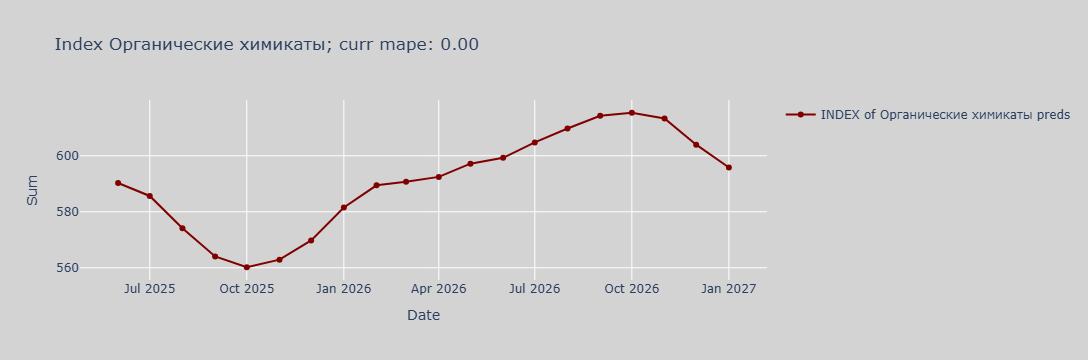

Saved forecaster to randomforest_dataset/randomforest_for_Органические химикаты__20.pkl and model to randomforest_dataset/randomforest_for_Органические химикаты__20_model.pth
Could not calculate mape for prediction due to index 0 is out of bounds for axis 0 with size 0


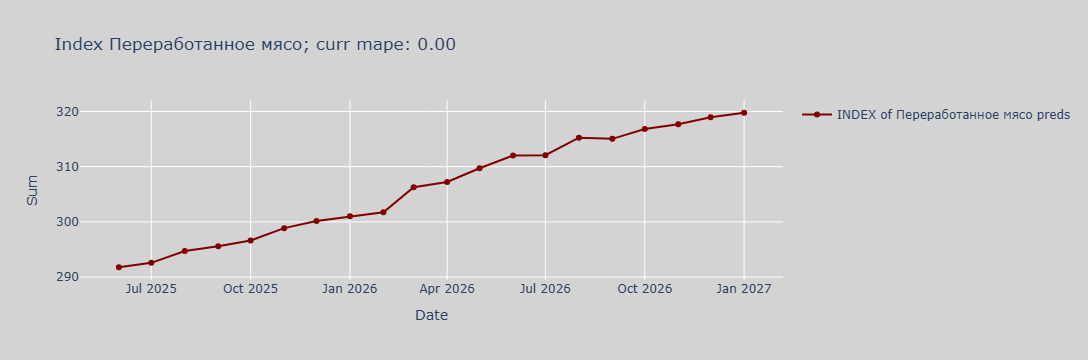

Saved forecaster to randomforest_dataset/randomforest_for_Переработанное мясо__20.pkl and model to randomforest_dataset/randomforest_for_Переработанное мясо__20_model.pth
Could not calculate mape for prediction due to index 0 is out of bounds for axis 0 with size 0


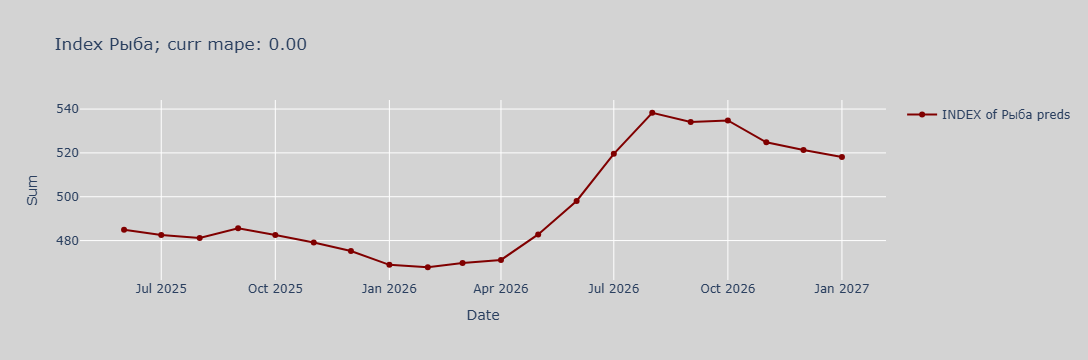

Saved forecaster to randomforest_dataset/randomforest_for_Рыба__20.pkl and model to randomforest_dataset/randomforest_for_Рыба__20_model.pth
Could not calculate mape for prediction due to index 0 is out of bounds for axis 0 with size 0


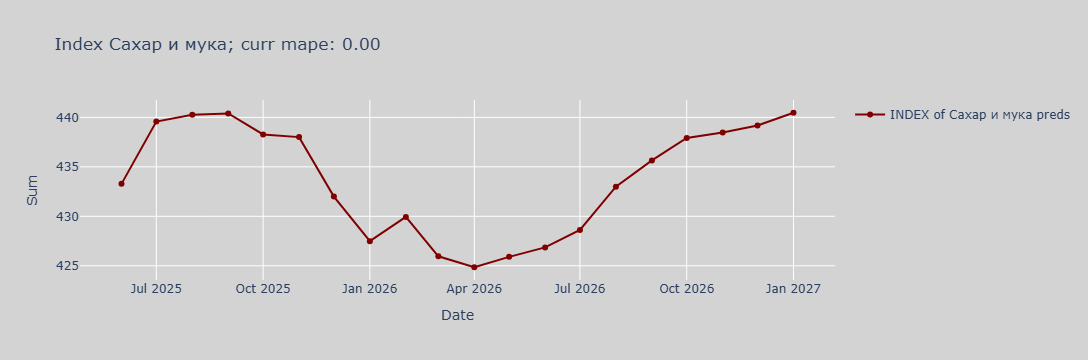

Saved forecaster to randomforest_dataset/randomforest_for_Сахар и мука__20.pkl and model to randomforest_dataset/randomforest_for_Сахар и мука__20_model.pth
Could not calculate mape for prediction due to index 0 is out of bounds for axis 0 with size 0


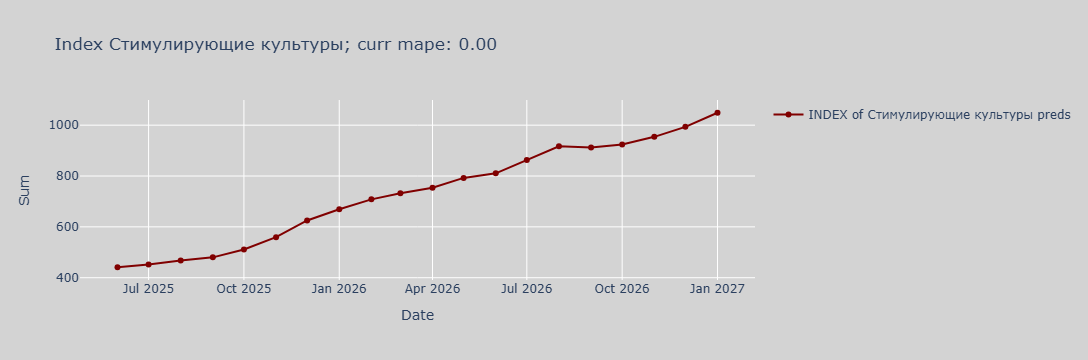

Saved forecaster to randomforest_dataset/randomforest_for_Стимулирующие культуры__20.pkl and model to randomforest_dataset/randomforest_for_Стимулирующие культуры__20_model.pth
Warning! The additional cluster column does not exists in cluster_data
Warning! There is no Unexsiting category_norm_sum at df
Could not calculate mape for prediction due to index 0 is out of bounds for axis 0 with size 0


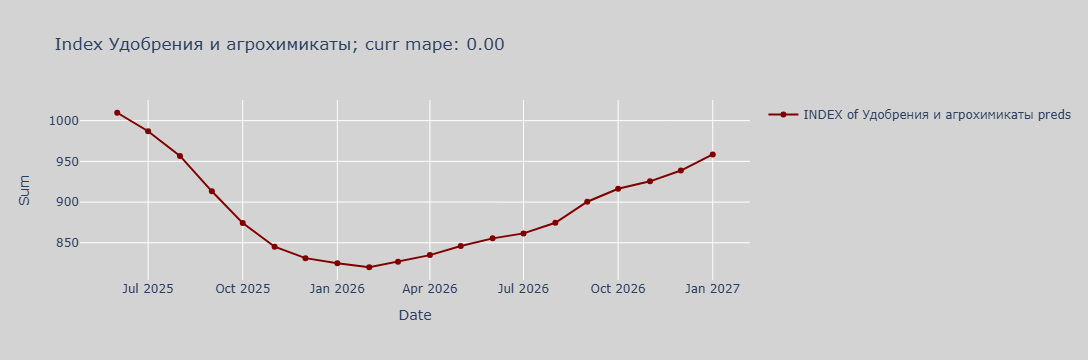

Saved forecaster to randomforest_dataset/randomforest_for_Удобрения и агрохимикаты__20.pkl and model to randomforest_dataset/randomforest_for_Удобрения и агрохимикаты__20_model.pth


In [4]:
models = train_model_and_eval_res(df_updated,
                         macro_updated,
                         past_idx = past_idx,
                         future_idx = future_idx,
                         predict_up_to=SINGLE_DATAPOINT_TO_PRED,
                         category_map = CATEGORY_MAP,
                         best_predictors_for_idx = BEST_PREDICTORS_FOR_INDEX,
                         target_col_suffix = TARGET_COL_SUFFIX,
                         future_forecaster_ts_name = FUTURE_FORECASTER_TS_NAME,
                         future_forecaster_ts_values = FUTURE_FORECASTER_TS_VALUES,
                         model_name = MODEL_NAME_FOR_FORECASTER,
                         use_future_macro = USE_FUTURE_COV,
                         prediction_horizon = PREDICTION_HORIZON,
                         dir_to_save_plots = f"darts_result_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         dir_to_save_tables = f"darts_result_tables_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         persist_model=PERSIST_MODEL,
                         refit=REFIT_MODEL,
                         prediction_lag=PREDICTOR_LAG,
                         is_backtest=IS_BACKTEST,
                         ts_freq=TS_FREQUENCY,
                         pred_index=new_dates
)

---
## Inference model

In [5]:
print(MODEL_SAVE_PATH)
models = load_models(MODEL_NAME_FOR_FORECASTER, MODEL_SAVE_PATH)

{model_name}_dataset/{model_name}_for_{category_name}__20
[OK] Loaded forecaster ← randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),__20.pkl
[OK] Loaded model      ← randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),__20_model.pth
[OK] Loaded forecaster ← randomforest_dataset/randomforest_for_Масла и шроты__20.pkl
[OK] Loaded model      ← randomforest_dataset/randomforest_for_Масла и шроты__20_model.pth
[OK] Loaded forecaster ← randomforest_dataset/randomforest_for_Переработанное мясо__20.pkl
[OK] Loaded model      ← randomforest_dataset/randomforest_for_Переработанное мясо__20_model.pth
[OK] Loaded forecaster ← randomforest_dataset/randomforest_for_Ключевая ставка, годовых__20.pkl
[OK] Loaded model      ← randomforest_dataset/randomforest_for_Ключевая ставка, годовых__20_model.pth
[OK] Loaded forecaster ← randomforest_dataset/randomforest_for_Орган

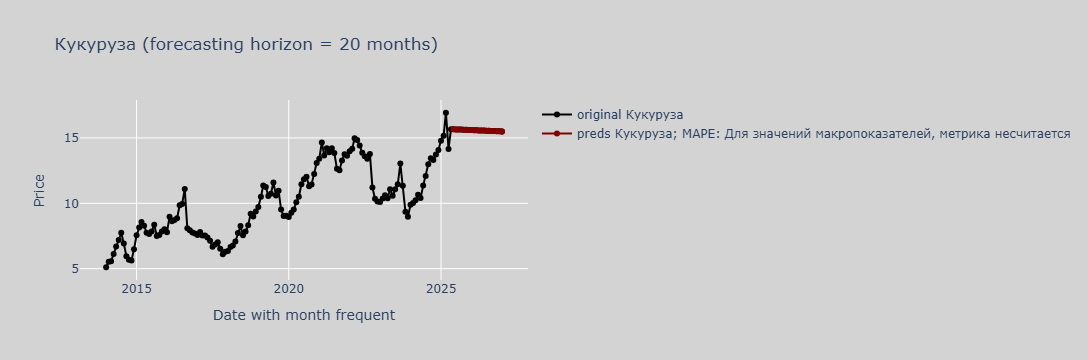

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


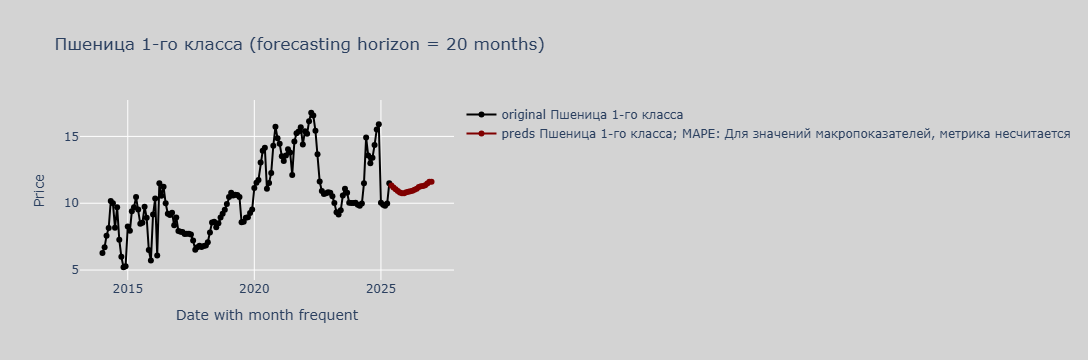

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


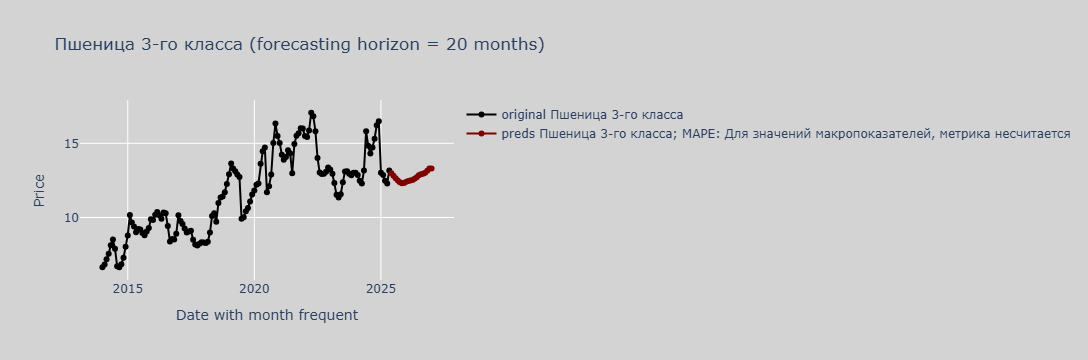

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


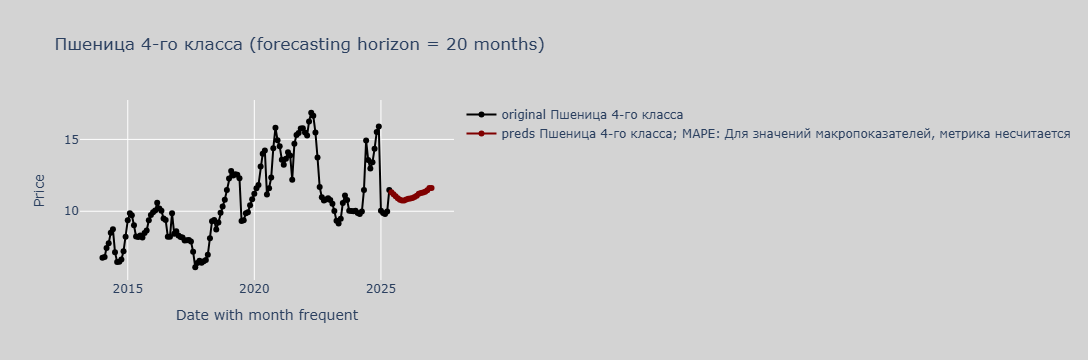

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


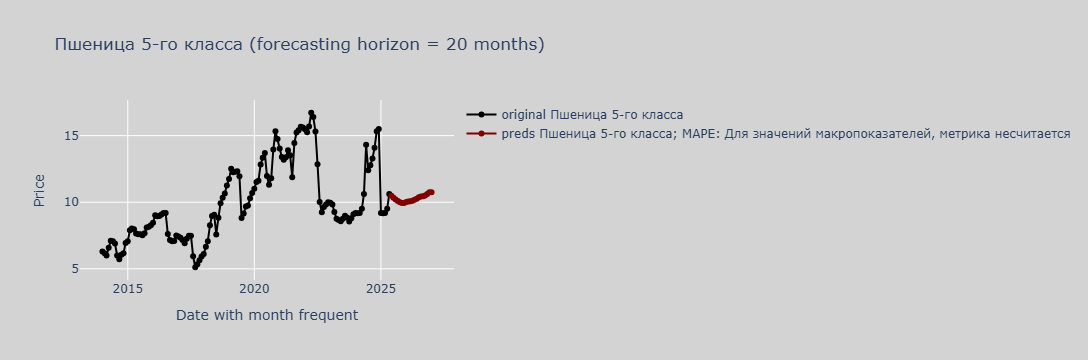

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


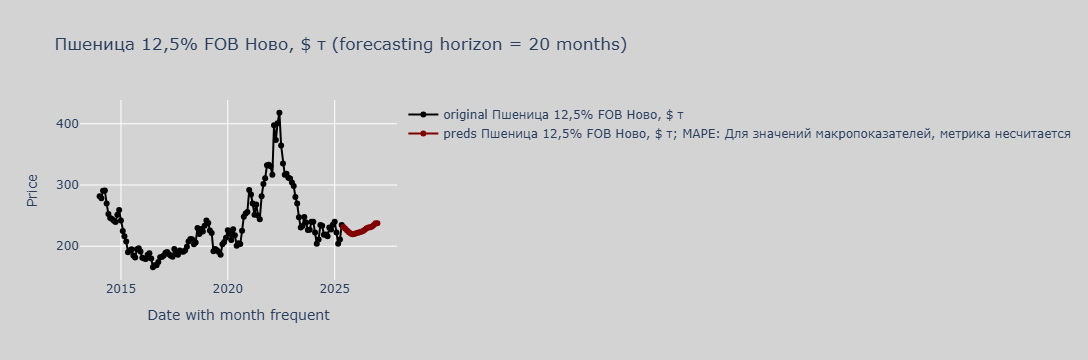

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


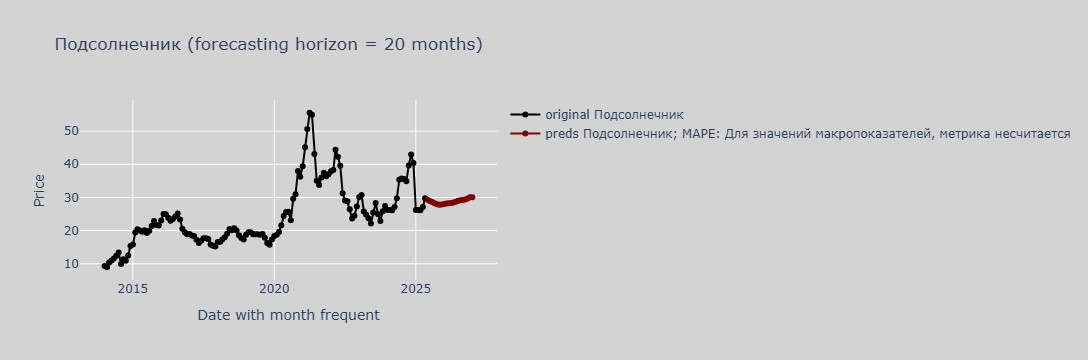

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


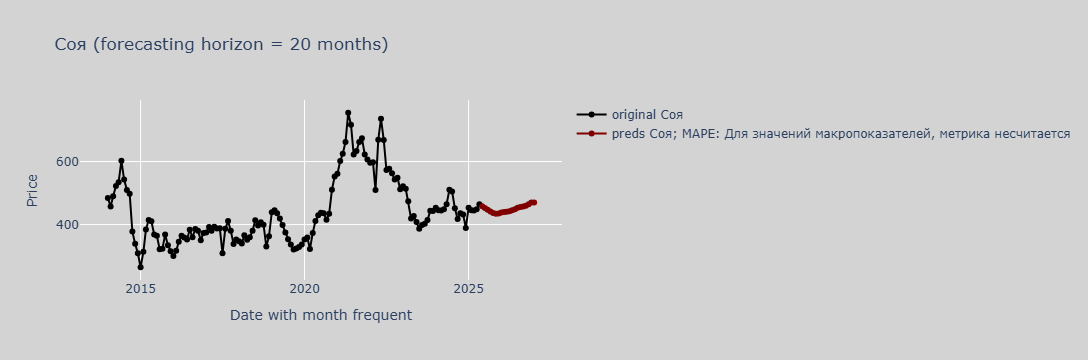

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


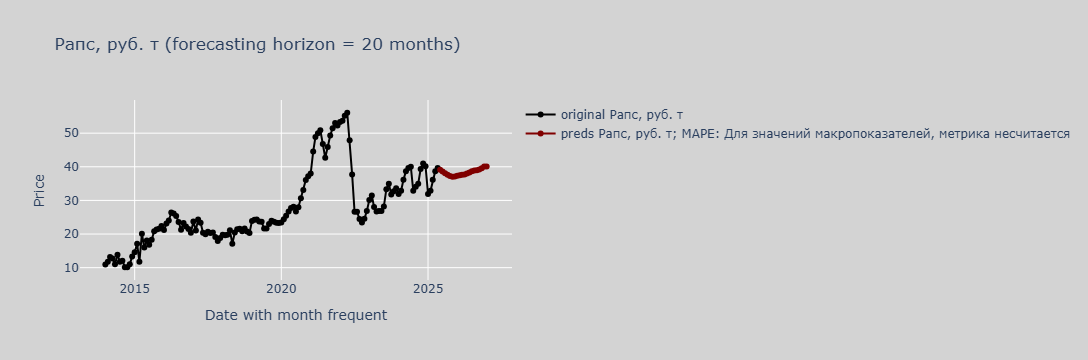

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


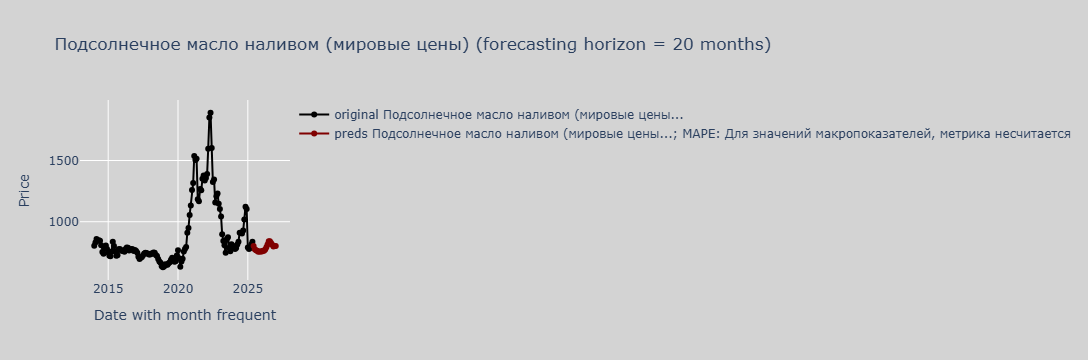

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


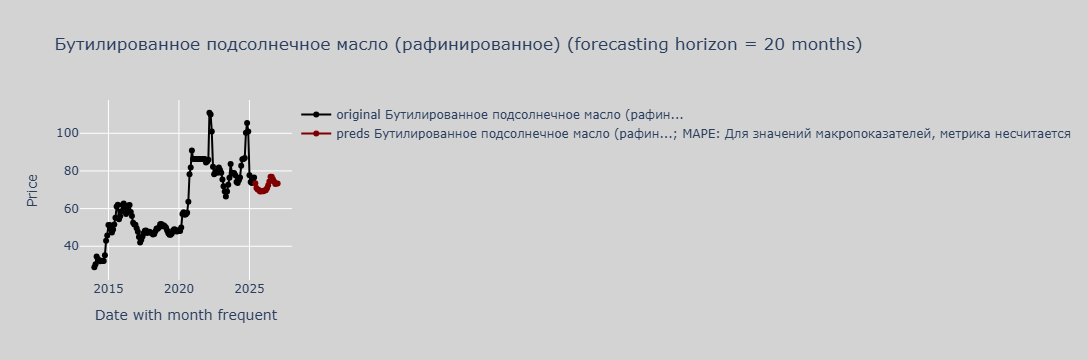

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


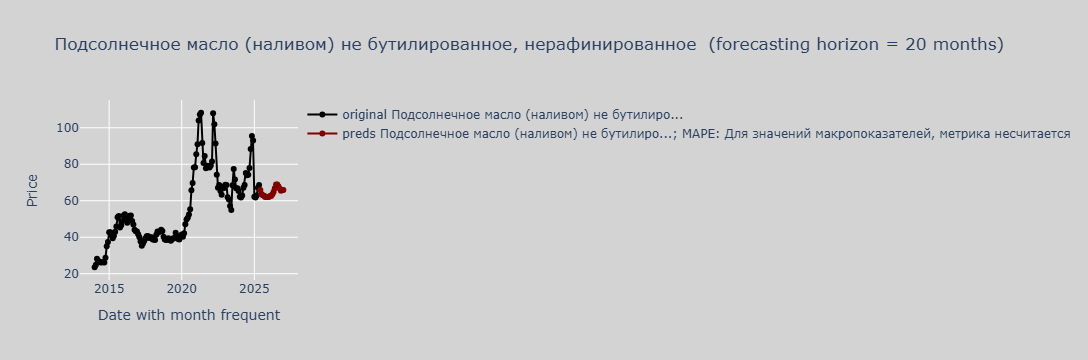

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


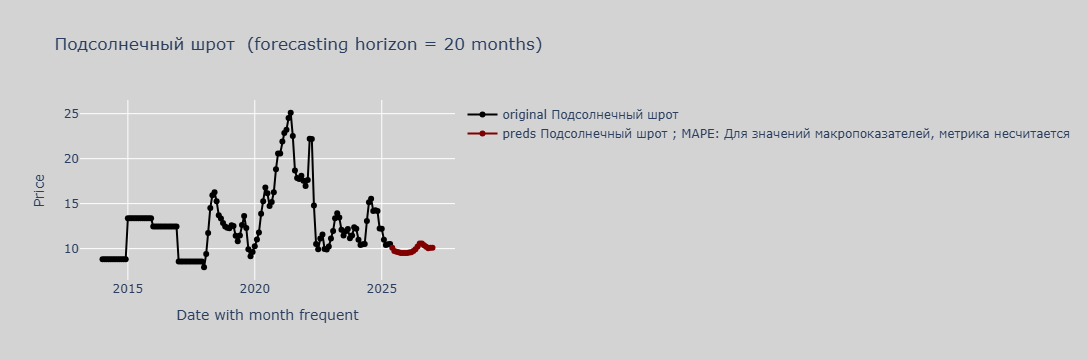

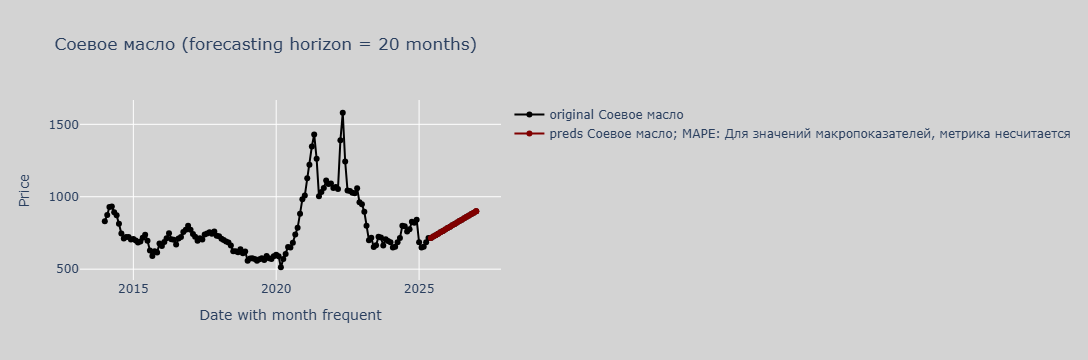

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


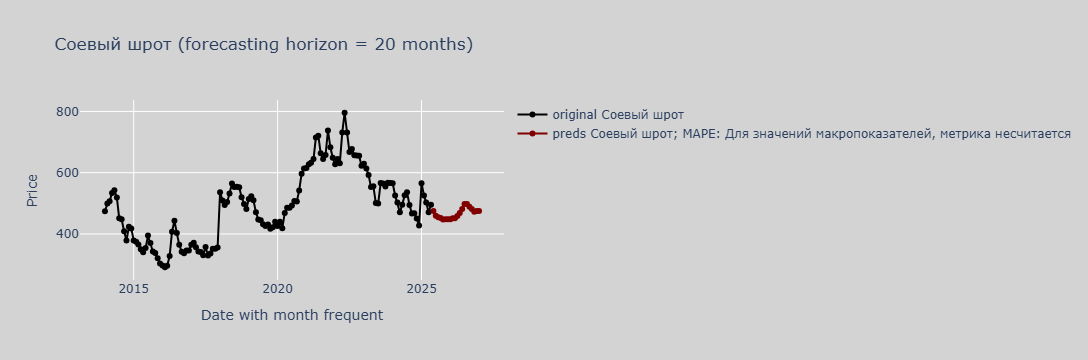

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


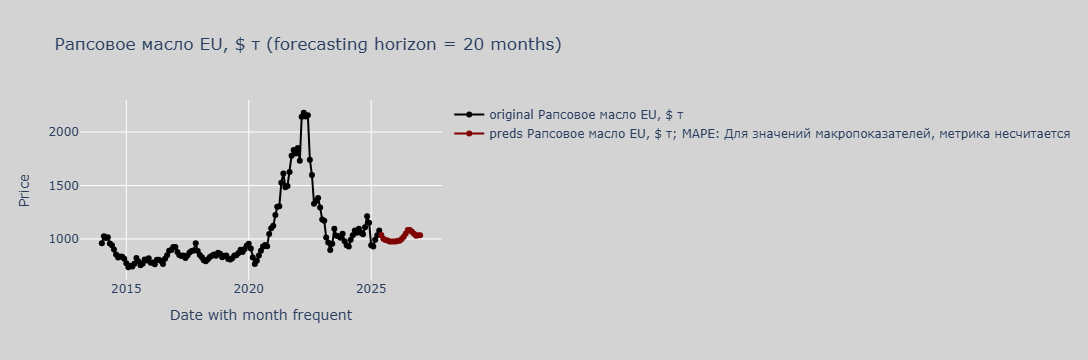

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


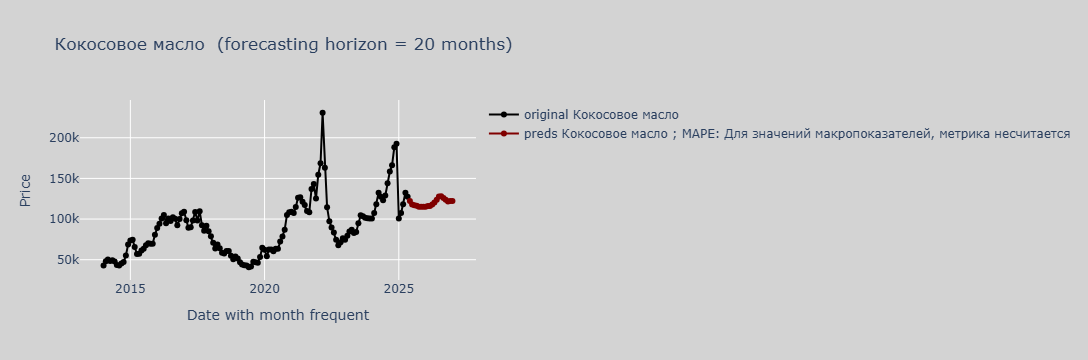

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


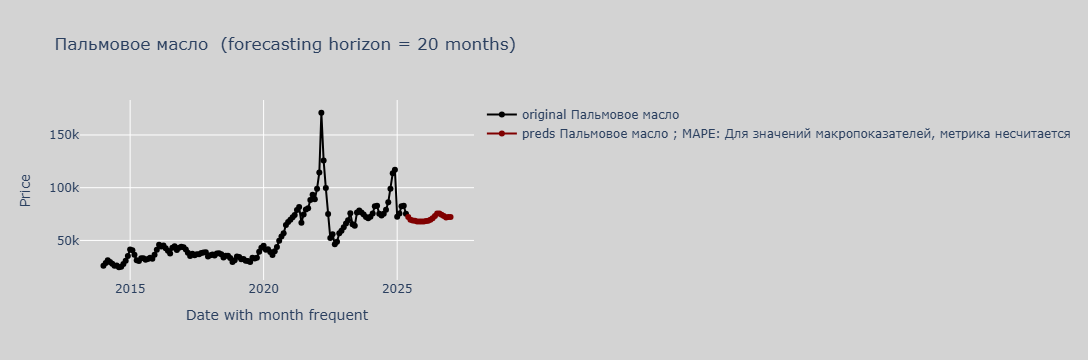

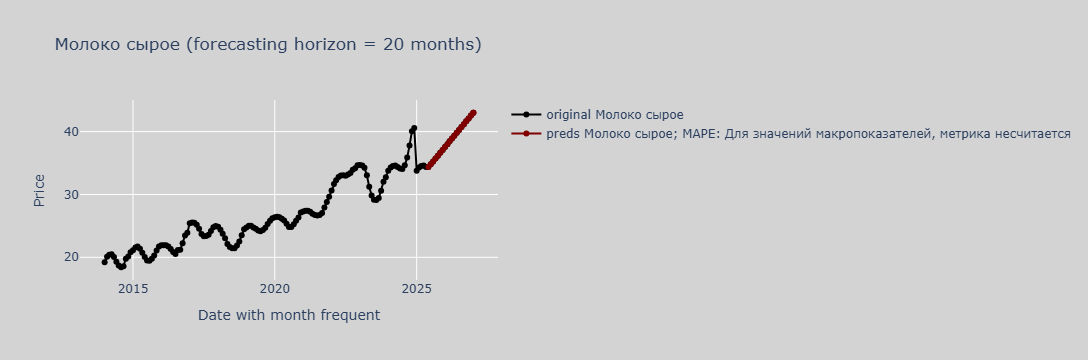

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


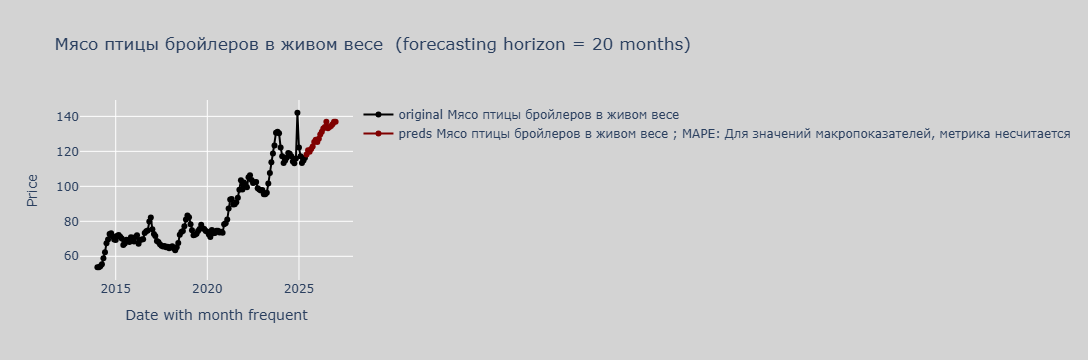

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


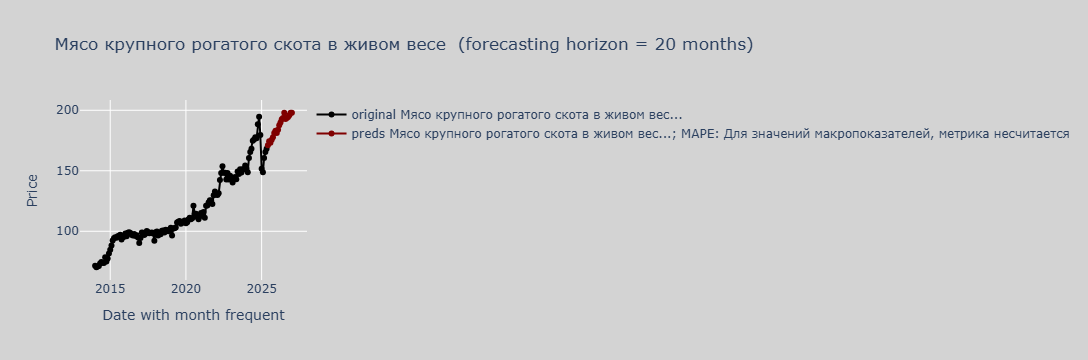

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


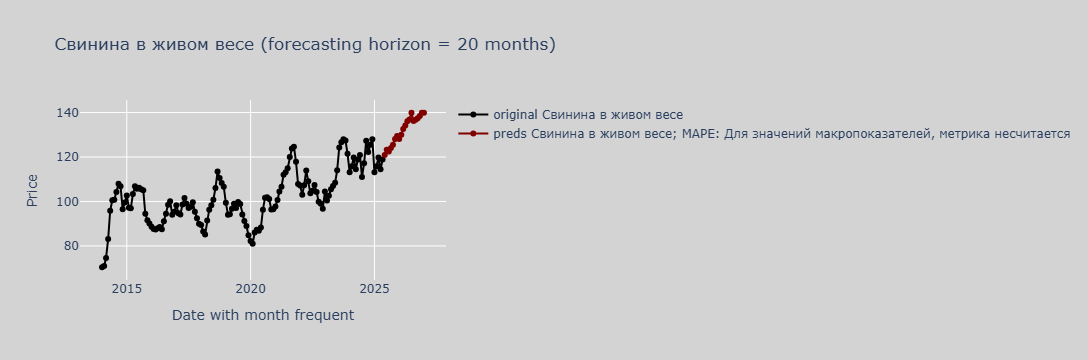

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


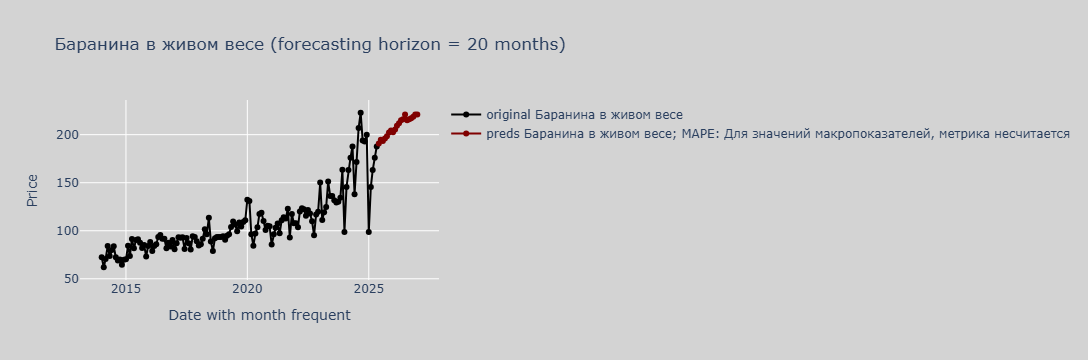

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


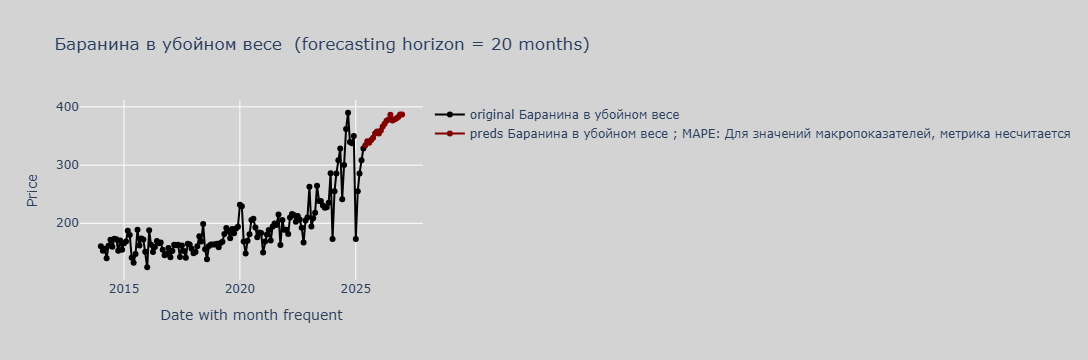

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


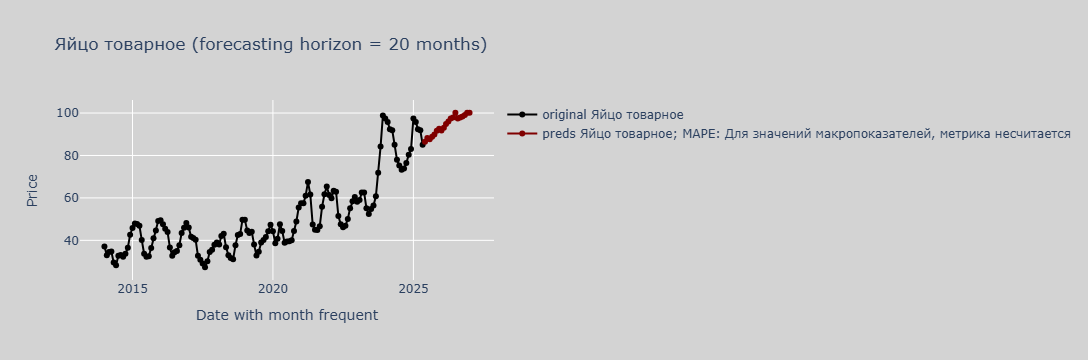

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


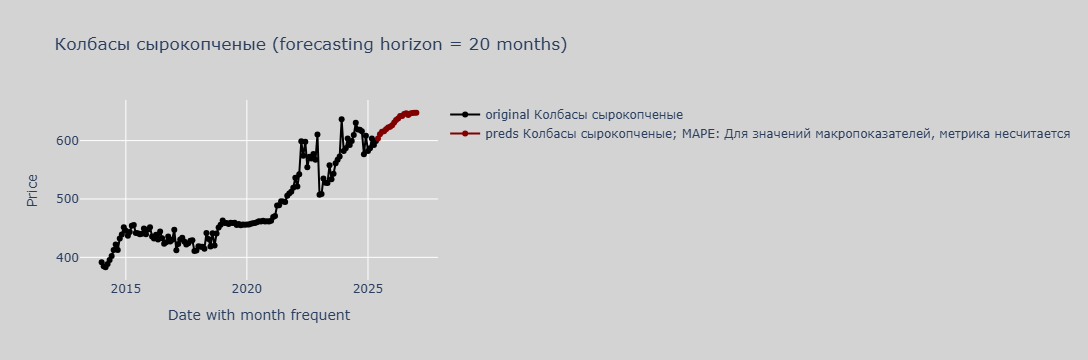

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


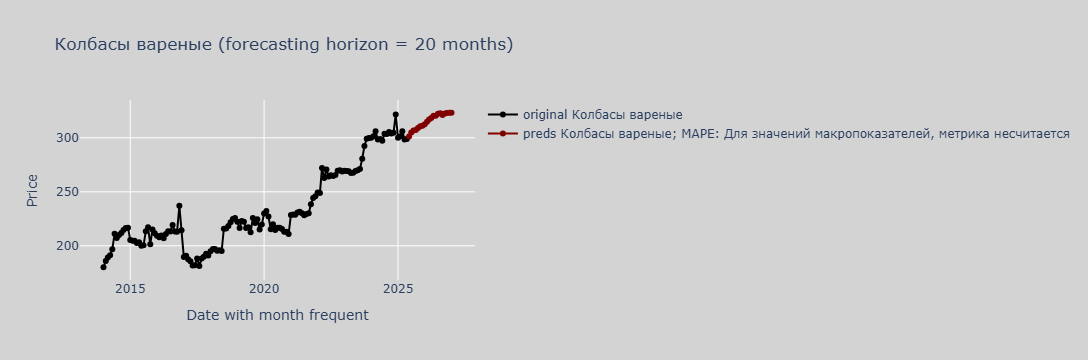

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


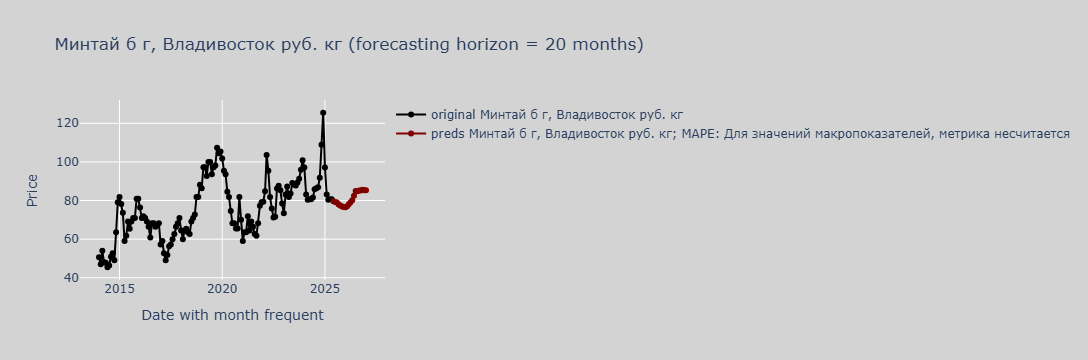

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


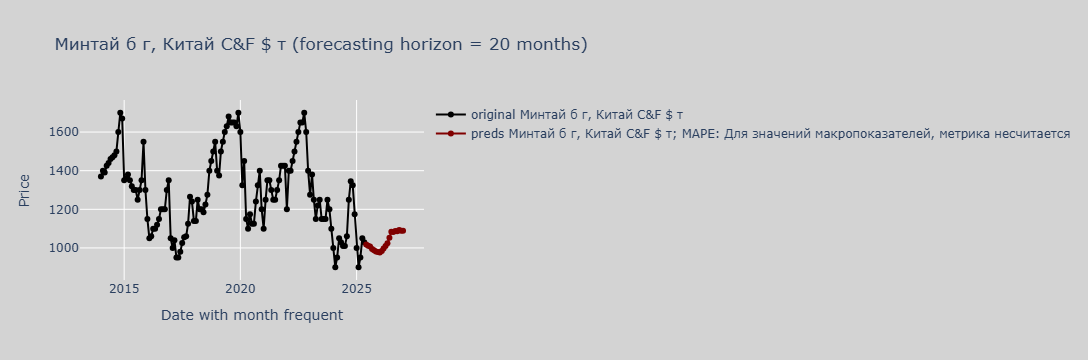

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


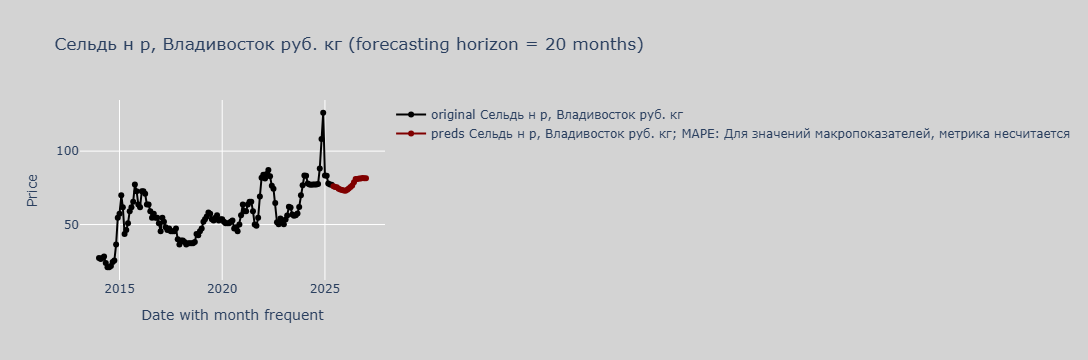

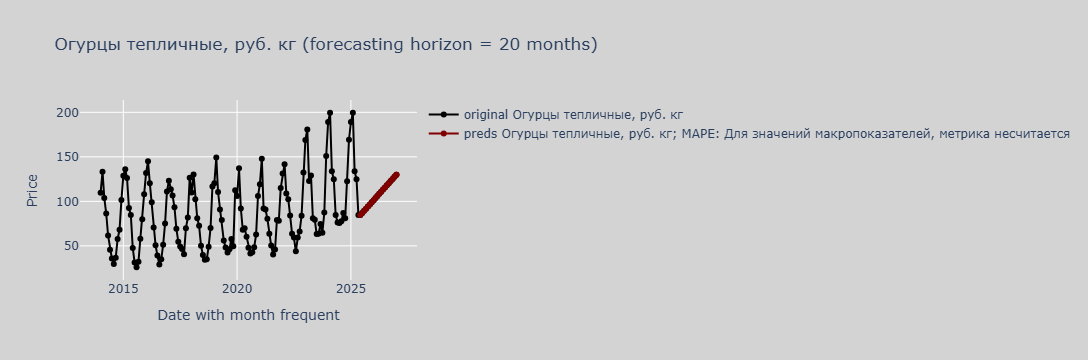

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


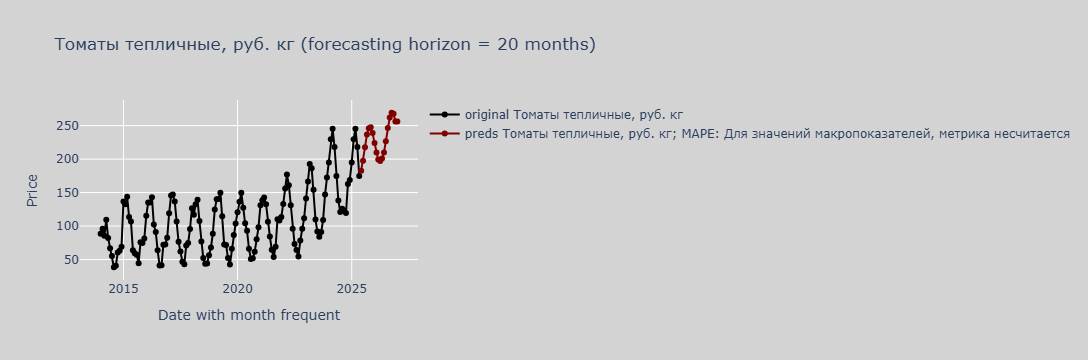

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


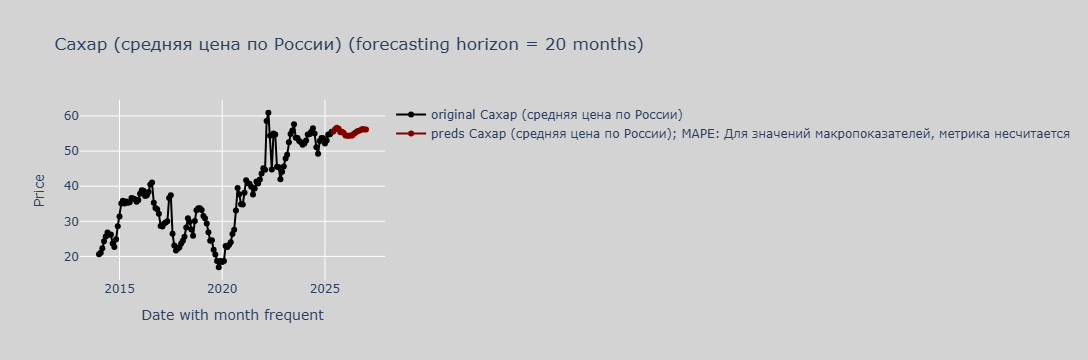

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


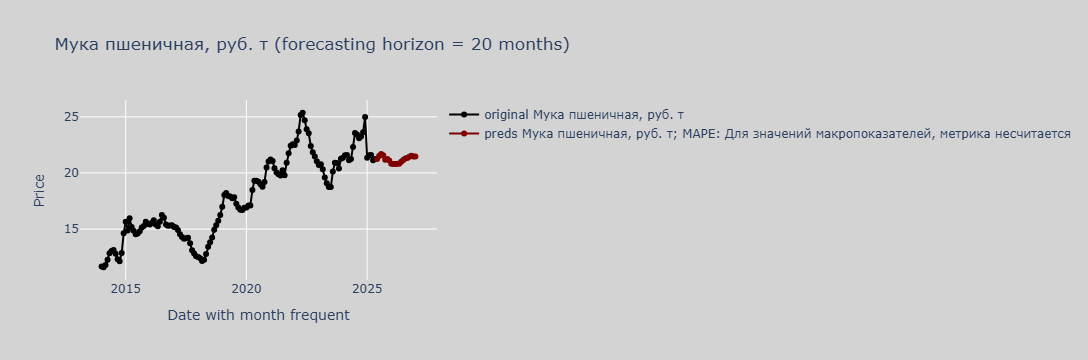

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


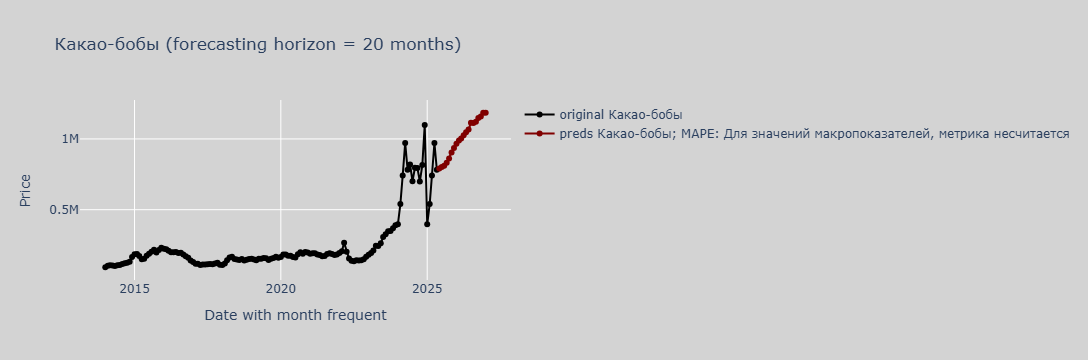

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


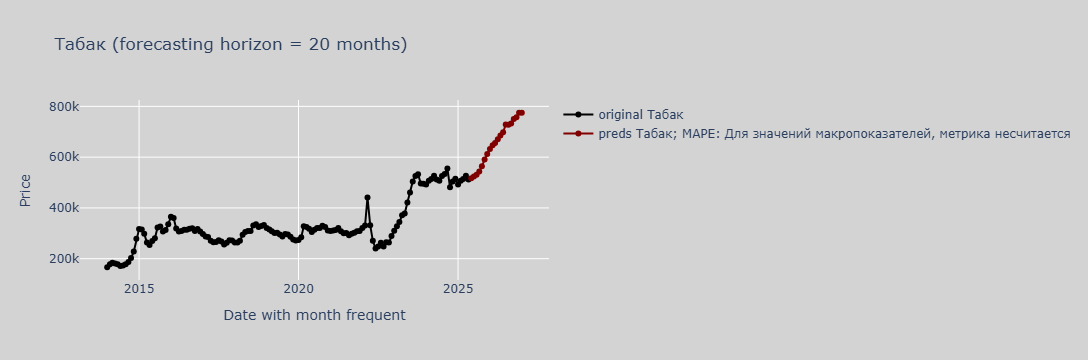

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


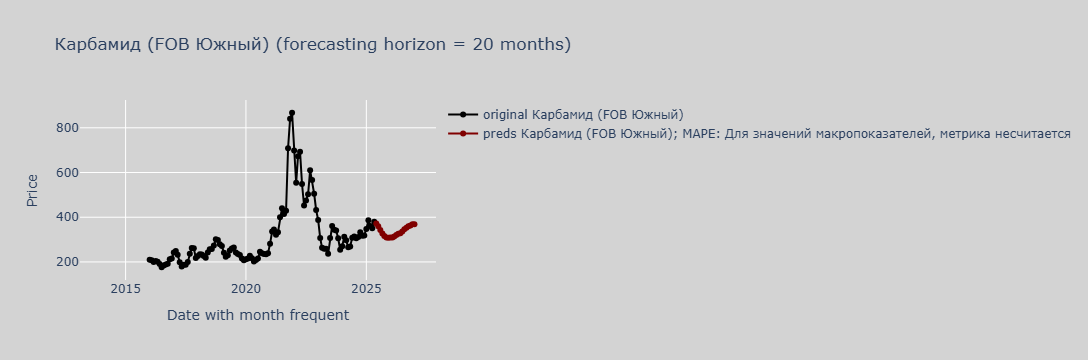

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


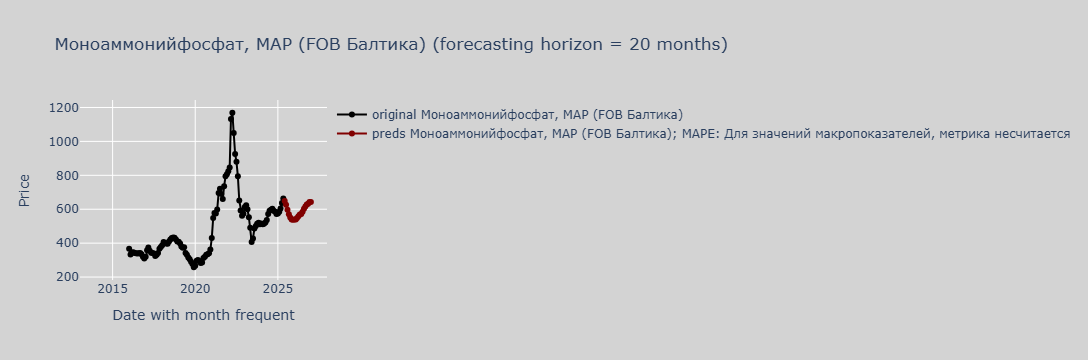

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


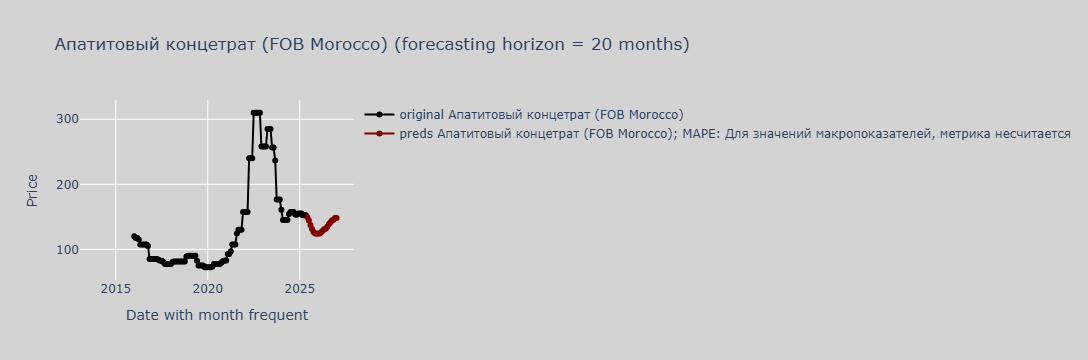

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


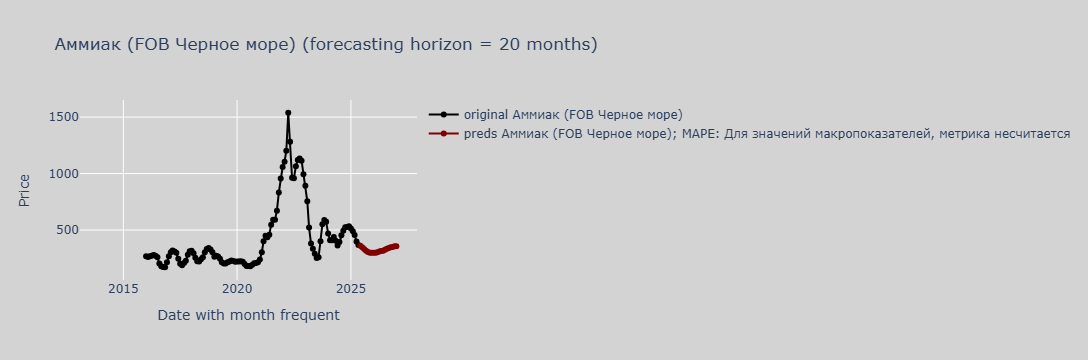

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


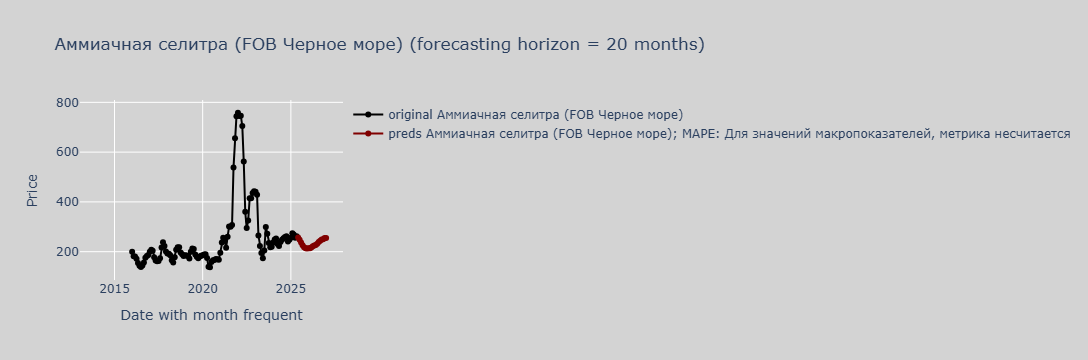

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


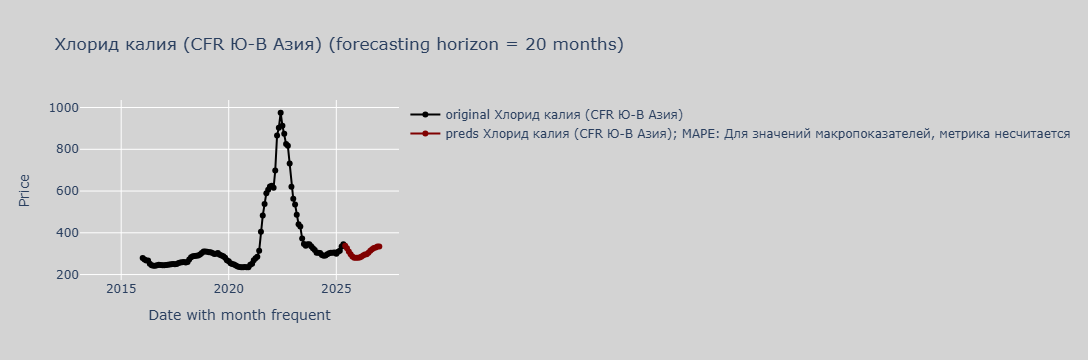

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


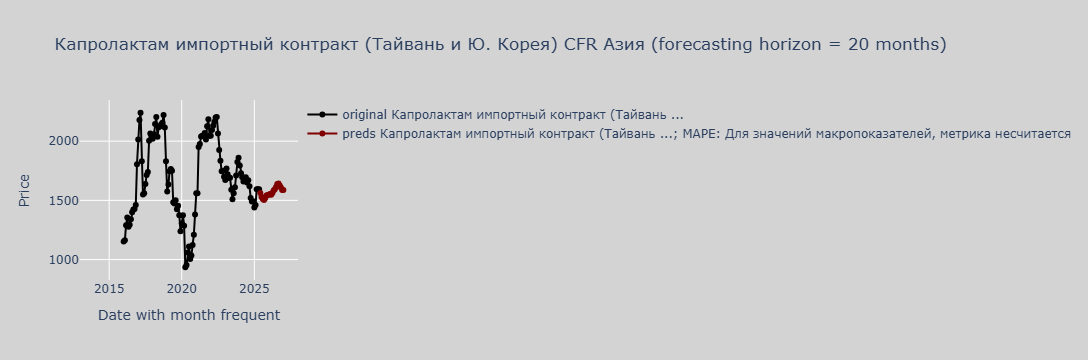

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


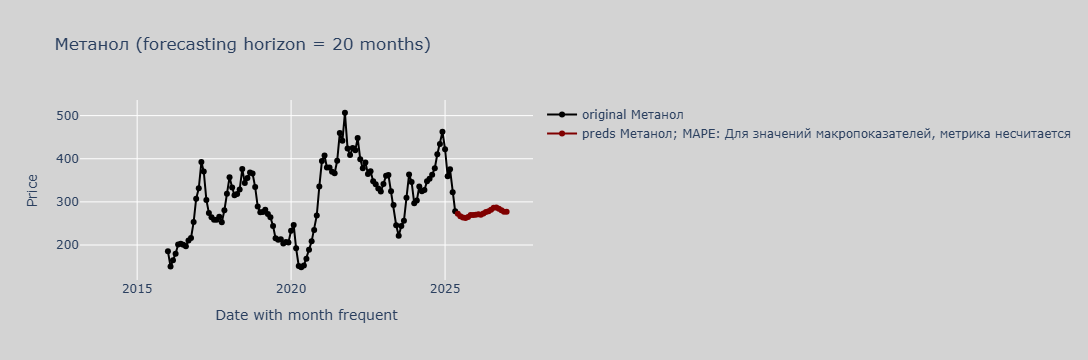

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


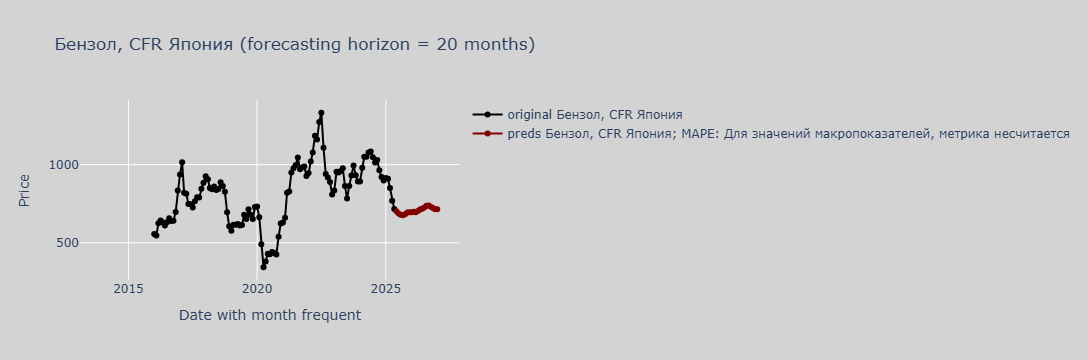

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


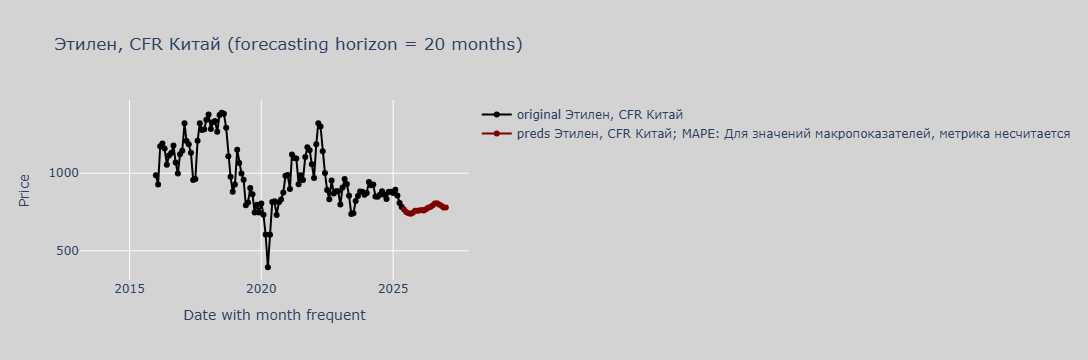

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]


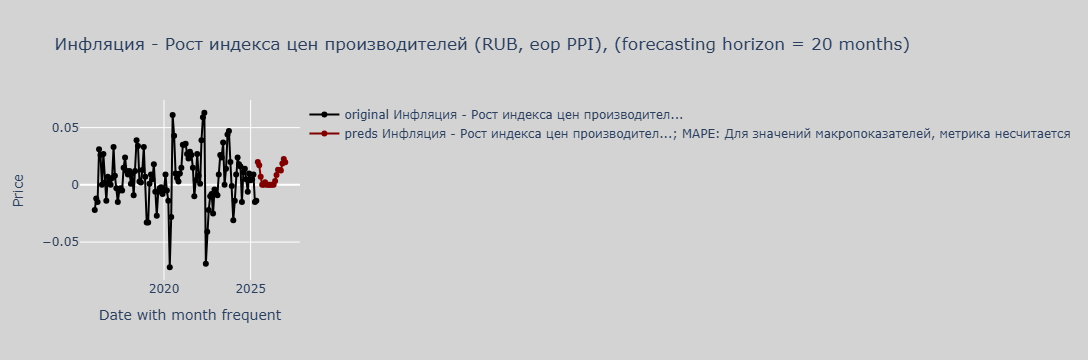

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]


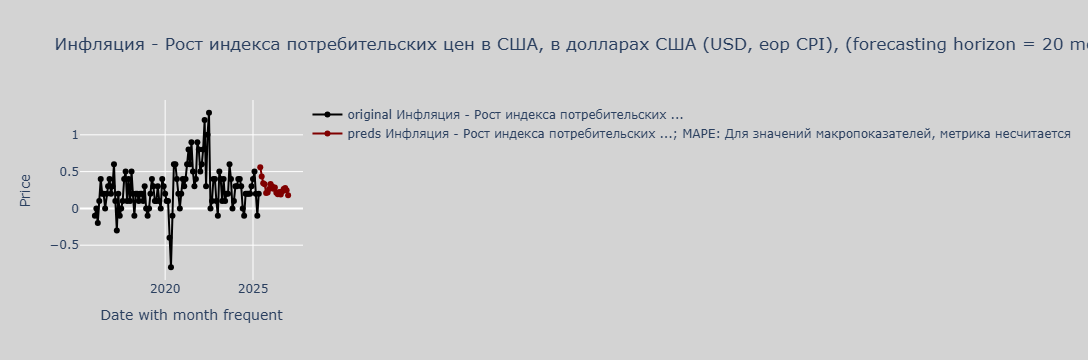

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]


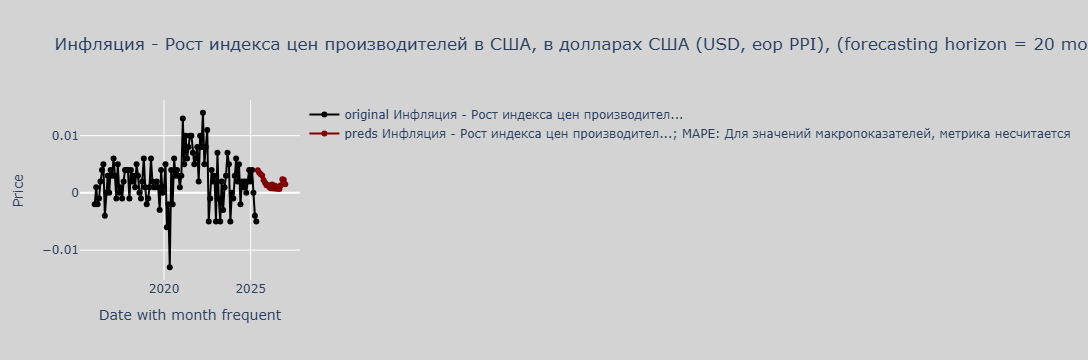

Warning! There is no Инфляция - Рост индекса цен производителей (RUB, eop PPI),_norm_sum at df
changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]


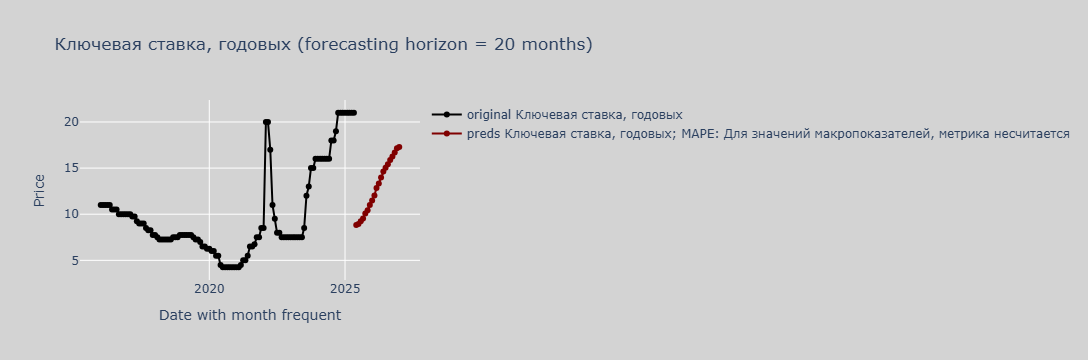

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]


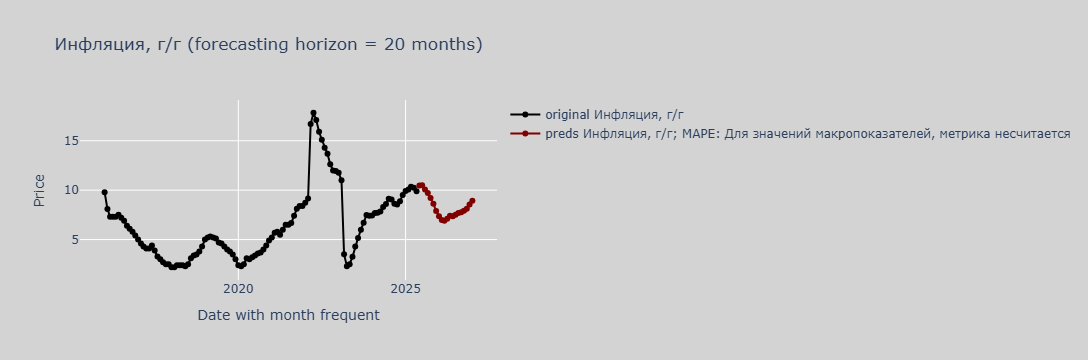

changes = [np.float64(0.0), np.float64(-0.0005440625103966257), np.float64(-0.0010881250207931403), np.float64(-0.001632187531189766), np.float64(-0.0021762500415862807), np.float64(-0.0027203125519829063), np.float64(-0.003264375062379421), np.float64(-0.0038084375727760467), np.float64(-0.004352500083172561), np.float64(-0.004896562593569187), np.float64(-0.005440625103965702), np.float64(-0.005984687614362327), np.float64(-0.006528750124758842), np.float64(-0.007072812635155357), np.float64(-0.007616875145551871), np.float64(-0.008160937655948497), np.float64(-0.008705000166345012), np.float64(-0.009249062676741637), np.float64(-0.009793125187138152), np.float64(-0.010337187697534778)]
2025-05-01 00:00:00


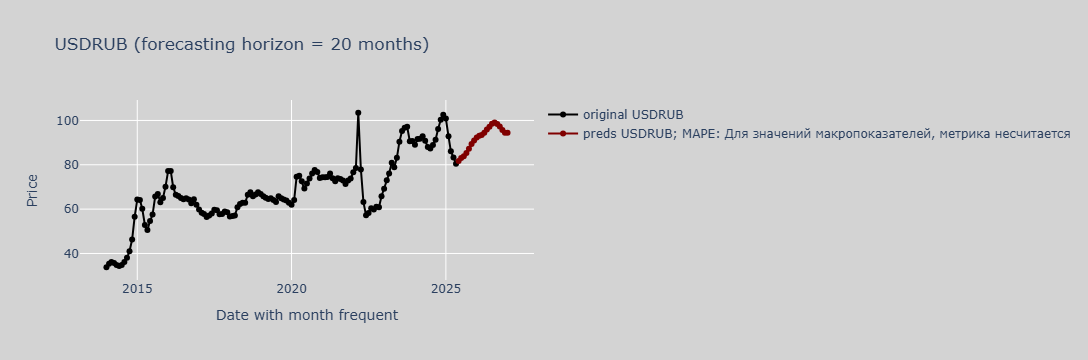

In [6]:
from sklearn.metrics import mean_absolute_percentage_error as mape


answer_last = pd.DataFrame([])
df_updated.columns = [col_name.replace("/", " ") for col_name in df_updated.columns]
mape_values = {}
processed_columns = []
for col in list(CATEGORY_MAP.keys()):
    is_predicting_macro = col in macro_updated.columns
    df_for_col = macro_updated if is_predicting_macro else df_updated
    if col in ('Подсолнечное масло (наливом) не бутилированное, не'):
        continue
    category_to_pred = CATEGORY_MAP.get(col, "")
    if category_to_pred == "":
        continue

    cluster_preds, ts_prediction = get_prediction_for_ts(df_updated,
                                                          models[category_to_pred],
                                                          col,
                                                          MODEL_NAME_FOR_FORECASTER,
                                                          macro_updated,
                                                          past_idx,
                                                          future_idx,
                                                          CATEGORY_MAP,
                                                          BEST_PREDICTORS_FOR_INDEX,
                                                          TARGET_COL_SUFFIX,
                                                          FUTURE_FORECASTER_TS_NAME,
                                                          FUTURE_FORECASTER_TS_VALUES,
                                                          USE_FUTURE_COV,
                                                          PREDICTION_HORIZON,
                                                          IS_BACKTEST,
                                                          PREDICTOR_LAG,
                                                          new_dates
                                                        )
    processed_columns.append(col)
    answer_last = pd.concat([answer_last, ts_prediction], axis=1)
    if not is_predicting_macro:
        mape_val = mape(df_for_col.loc[ts_prediction.index][col], ts_prediction[f"{col}_preds"]) if IS_BACKTEST else 0
    else:
        mape_val = None
    mape_values[col] = mape_val
    plot_graphics_for_each_ts(df_for_col[f"{col}"],
                          ts_prediction[f"{col}_preds"],
                          None,
                          col,
                          mape_val,
                          -1,
                          BEST_PREDICTORS_FOR_INDEX[CATEGORY_MAP[col]],
                          "",
                          forecasting_horizon=PREDICTION_HORIZON)

In [7]:
exclude = ['Подсолнечное масло (наливом) не бутилированное, не', 'Инфляция - Рост индекса цен производителей (RUB, eop PPI),', 'Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),', 'Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),', 'Ключевая ставка, годовых', 'Инфляция, г/г']
result = [x for x in list(CATEGORY_MAP.keys()) if x not in exclude]

answer_last = answer_last.filter(regex='_preds')
answer_last = answer_last.loc[:,~answer_last.columns.duplicated()].copy()
answer_last.columns = [i.replace('_preds', '') for i in answer_last.columns]

col_to_keep = df_updated[result][list(set(FUTURE_FORECASTER_TS_NAME) - set(macro_data))]
to_save = answer_last.reindex(df_updated[result].index).combine_first(df_updated[result])
to_save[list(set(FUTURE_FORECASTER_TS_NAME) - set(macro_data))] = col_to_keep
to_save = macro_data.reindex(to_save.index).combine_first(to_save)

to_save = to_save[list(mape_values.keys())]

In [10]:
from openpyxl import load_workbook
from openpyxl.styles import PatternFill
from openpyxl.styles import Border, Side
import datetime


file_name = f"prediction_{MODEL_NAME_FOR_FORECASTER}_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}.xlsx"
to_save.to_excel(file_name)

wb = load_workbook(file_name)
ws = wb.active

first_idx = answer_last.index[0]
row_num = list(to_save.index).index(first_idx) + 2 

cols_to_fill = list(FUTURE_VALUES.keys())
col_indices = [idx + 1 for idx, cell in enumerate(ws[1]) if cell.value in cols_to_fill]

fill_yellow = PatternFill(start_color="FFFF00", end_color="FFFF00", fill_type="solid")
for col in range(1, ws.max_column + 1):
    ws.cell(row=row_num, column=col).fill = fill_yellow

fill_red = PatternFill(start_color="FF0000", end_color="FF0000", fill_type="solid")
for col in col_indices:
    for row in range(row_num, ws.max_row + 1):
        ws.cell(row=row, column=col).fill = fill_red


# тонкая жирная линия
thick_side = Side(style="medium")
headers = [cell.value for cell in ws[1]]
clusters = [CATEGORY_MAP.get(col) for col in headers]

cluster_borders = []
for i in range(len(clusters) - 1):
    if clusters[i] != clusters[i + 1]:
        cluster_borders.append(i + 1)

for col_idx in cluster_borders:
    for row in range(1, ws.max_row + 1):
        left_cell = ws.cell(row=row, column=col_idx)
        right_cell = ws.cell(row=row, column=col_idx + 1)

        left_cell.border = Border(
            left=left_cell.border.left,
            right=thick_side,
            top=left_cell.border.top,
            bottom=left_cell.border.bottom,
        )
        right_cell.border = Border(
            left=thick_side,
            right=right_cell.border.right,
            top=right_cell.border.top,
            bottom=right_cell.border.bottom,
        )

wb.save(file_name)


In [11]:
import pandas as pd
import numpy as np
from openpyxl import Workbook

def add_cluster_row_borders(ws, index_values):
    medium_side = Side(style="medium")
    clusters = [CATEGORY_MAP.get(v) for v in index_values]

    # границы между строками кластеров
    for i in range(len(clusters) - 1):
        if clusters[i] != clusters[i + 1]:
            excel_row = i + 2  # +1 header, +1 Excel-нумерация
            for col in range(1, ws.max_column + 1):
                upper = ws.cell(row=excel_row, column=col)
                lower = ws.cell(row=excel_row + 1, column=col)

                upper.border = Border(
                    left=upper.border.left,
                    right=upper.border.right,
                    top=upper.border.top,
                    bottom=medium_side,
                )
                lower.border = Border(
                    left=lower.border.left,
                    right=lower.border.right,
                    top=medium_side,
                    bottom=lower.border.bottom,
                )


def save_pointwise_metrics(real_data: pd.DataFrame, predictions: pd.DataFrame, excel_path="metrics.xlsx"):
    if real_data.shape != predictions.shape:
        raise ValueError("real_data и predictions должны иметь одинаковую форму")

    # Поточечный MAPE
    mape_pointwise = (np.abs(real_data.values - predictions.values) / real_data.values) * 100
    mape_df = pd.DataFrame(mape_pointwise, index=predictions.index, columns=predictions.columns)

    # Поточечный SMAPE
    smape_pointwise = (2 * np.abs(real_data.values - predictions.values) / 
                       (np.abs(real_data.values) + np.abs(predictions.values))) * 100
    smape_df = pd.DataFrame(smape_pointwise, index=predictions.index, columns=predictions.columns)

    wb = Workbook()

    # Лист MAPE
    ws_mape = wb.active
    ws_mape.title = "MAPE"

    mape_t = mape_df.T
    ws_mape.append(["Index"] + list(mape_t.columns))
    for idx, row in mape_t.iterrows():
        ws_mape.append([idx] + row.tolist())
        
    add_cluster_row_borders(ws_mape, list(mape_t.index))

    # Лист SMAPE
    ws_smape = wb.create_sheet(title="SMAPE")

    smape_t = smape_df.T
    ws_smape.append(["Index"] + list(smape_t.columns))
    for idx, row in smape_t.iterrows():
        ws_smape.append([idx] + row.tolist())

    add_cluster_row_borders(ws_smape, list(smape_t.index))

    # Сохраняем
    wb.save(excel_path)

In [12]:
if IS_BACKTEST:
    real_matrix = pd.concat(
    [df_combined.loc[(df_combined.index <= past_idx[-1]) & (df_combined.index > past_idx[-1] - pd.DateOffset(months=BACKTEST_PREDICTION_RANGE))],
     macro_data.loc[df_combined[(df_combined.index <= past_idx[-1]) & (df_combined.index > past_idx[-1] - pd.DateOffset(months=BACKTEST_PREDICTION_RANGE))].index]],
    axis=1
    )[answer_last.columns]

    mape_filename = f"metrics_pointwise_{MODEL_NAME_FOR_FORECASTER}_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}.xlsx"

    real_quarterly = real_matrix.resample('Q').mean()
    pred_quarterly = answer_last.resample('Q').mean()

    real_yearly = real_matrix.resample('Y').mean()
    pred_yearly = answer_last.resample('Y').mean()

    save_pointwise_metrics(real_data=real_matrix, predictions=answer_last, excel_path=f'M_{mape_filename}')
    save_pointwise_metrics(real_data=real_quarterly, predictions=pred_quarterly, excel_path=f'Q_{mape_filename}')
    save_pointwise_metrics(real_data=real_yearly, predictions=pred_yearly, excel_path=f'Y_{mape_filename}')